# Projet : Segmentation des Projets de Développement
## Clustering & Intelligence Artificielle 

**Réalisé par :** AKOTA Yao Jérôme 


## 2. Contexte et Objectifs

### 2.1 Contexte

La **Banque Ouest Africaine de Développement (BOAD)** est l'institution financière spécialisée
de l'Union Économique et Monétaire Ouest Africaine (UEMOA). Elle finance des centaines de
projets de développement dans les **8 pays membres** :

<table border="1" style="width:100%; border-collapse: collapse; text-align: center;">
    <tr text-align=center>
        <th>id</th>
        <th>Pays</th>
        <th>Capitale</th>
    </tr>
    <tr>
        <td>1</td>
         <td>🇧🇯 Bénin</td>
         <td>Porto-Novo</td>
    </tr>
    <tr>
        <td>2</td>
         <td> 🇧🇫 Burkina Faso</td>
         <td>Ouagadougou</td>
    </tr>
    <tr>
        <td>3</td>
         <td>🇨🇮 Côte d'Ivoire</td>
         <td>Yamoussoukro</td>
    </tr>
    <tr>
        <td>4</td>
         <td>🇬🇼 Guinée-Bissau</td>
         <td>Bissau</td>
    </tr>
    <tr>
        <td>5</td>
         <td>🇲🇱 Mali</td>
         <td>Bamako</td>
    </tr>
    <tr>
        <td>6</td>
         <td>🇳🇪 Niger</td>
         <td> Niamey</td>
    </tr>
    <tr>
        <td>7</td>
         <td>🇸🇳 Sénégal </td>
         <td>Dakar</td>
    </tr>
    <tr>
        <td>8</td>
         <td>🇹🇬 Togo</td>
         <td>Lomé</td>
    </tr>
</table>

Ces projets couvrent des secteurs variés : agriculture, énergie, transport, éducation, santé,
eau et assainissement, industrie, numérique. Avec un portefeuille aussi diversifié, il est
**essentiel de segmenter** ces projets pour optimiser la gestion du portefeuille, identifier
les similarités et les risques, et orienter les décisions stratégiques.

### 2.2 Objectifs

1. **Explorer** les données des projets de développement financés par la BOAD
2. **Appliquer des algorithmes d'apprentissage non supervisé** (K-Means, Clustering Hiérarchique)
   pour identifier des groupes naturels de projets
3. **Caractériser et nommer** chaque cluster identifié
4. **Formuler des recommandations** pour l'optimisation du portefeuille de la BOAD


## 3. Importation des Bibliothèques

Nous importons toutes les bibliothèques nécessaires à l'analyse de données,
à la visualisation et au clustering.


In [14]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
sns.set_theme(style="whitegrid", font_scale=1.1)


FIGURES_DIR = 'figures'
import os
os.makedirs(FIGURES_DIR, exist_ok=True)

## 4. Création du Jeu de Données Synthétique

Dans un contexte réel, ces données proviendraient de la base de données interne de la BOAD.
Pour ce projet de démonstration, nous créons un jeu de données synthétique réaliste de
**200 projets de développement** avec des caractéristiques pertinentes.



In [15]:
np.random.seed(42)


### 4.1 Définition des listes de référence

Nous définissons les listes de pays, de secteurs et de statuts qui seront utilisées
pour générer les données de chaque projet.


In [16]:
# Liste des 8 pays membres de l'UEMOA 
pays_uemoa = [
    "Bénin", "Burkina Faso", "Côte d'Ivoire", "Guinée-Bissau",
    "Mali", "Niger", "Sénégal", "Togo"
]

poids_pays = [0.10, 0.12, 0.20, 0.05, 0.12, 0.11, 0.18, 0.12]
secteurs = [
    "agriculture", "énergie", "transport", "éducation",
    "santé", "eau_assainissement", "industrie", "numérique"
]

poids_secteurs = [0.20, 0.15, 0.18, 0.10, 0.08, 0.12, 0.10, 0.07]
statuts = ["en_cours", "terminé", "en_étude", "suspendu"]
poids_statuts = [0.45, 0.30, 0.15, 0.10]


### 4.2 Génération des noms de projets réalistes

Nous créons des noms de projets réalistes en combinant des mots-clés
spécifiques à chaque secteur avec des noms de villes/régions des pays UEMOA.


In [17]:
# Dictionnaire de templates de noms par secteur 
templates_noms = {
    "agriculture": [
        "Programme Irrigué de {}", "Projet Rizicole de {}", "Ferme Modèle de {}",
        "Aménagement Hydro-Agricole de {}", "Projet Maraîcher de {}",
        "Coopérative Agricole de {}", "Projet Céréales de {}",
        "Développement Agricole Intégré de {}", "Projet Vivrier de {}",
        "Périmètre Irrigué de {}"
    ],
    "énergie": [
        "Centrale Solaire de {}", "Barrage Hydroélectrique de {}",
        "Réseau Électrique Rural de {}", "Parc Éolien de {}",
        "Électrification Rurale de {}", "Centrale Thermique de {}",
        "Projet Biogaz de {}", "Ligne Haute Tension {}-{}", "Projet Solaire de {}",
        "Interconnexion Énergétique {}-{}"
    ],
    "transport": [
        "Route Nationale {}-{}", "Aéroport International de {}",
        "Port Fluvial de {}", "Voie Ferrée {}-{}",
        "Pont sur le Fleuve à {}", "Route Bitumée {}-{}",
        "Autoroute de {}", "Réseau Routier de {}",
        "Gare Routière de {}", "Piste Rurale de {}"
    ],
    "éducation": [
        "École Primaire de {}", "Lycée de {}",
        "Université Régionale de {}", "Centre de Formation de {}",
        "Bibliothèque Municipale de {}", "Campus Numérique de {}",
        "Projet Éducatif de {}", "Formation Professionnelle de {}",
        "Complexes Scolaires de {}", "École Normale de {}"
    ],
    "santé": [
        "Hôpital Régional de {}", "Centre de Santé de {}",
        "Maternité de {}", "Centre de Dialyse de {}",
        "Hôpital Universitaire de {}", "Dispensaire de {}",
        "Projet Santé Maternelle de {}", "Centre Médical de {}",
        "Laboratoire d'Analyses de {}", "Pharmacie Hospitalière de {}"
    ],
    "eau_assainissement": [
        "Adduction d'Eau Potable de {}", "Station de Traitement de {}",
        "Réseau d'Assainissement de {}", "Forage de {}",
        "Barrage de Retenue de {}", "Système d'Irrigation de {}",
        "Assainissement Urbain de {}", "Captage d'Eau de {}",
        "Réseau d'Eau de {}", "Traitement des Eaux Usées de {}"
    ],
    "industrie": [
        "Zone Industrielle de {}", "Usine de Transformation de {}",
        "Plateforme Logistique de {}", "Parc Industriel de {}",
        "Unité de Production de {}", "Cimenterie de {}",
        "Usine Agroalimentaire de {}", "Technopôle de {}",
        "Zone Franche de {}", "Unité de Conditionnement de {}"
    ],
    "numérique": [
        "Fibre Optique de {}", "Centre de Données de {}",
        "Plateforme Numérique de {}", "E-Gouvernement de {}",
        "Réseau Télécom de {}", "Incubateur Numérique de {}",
        "Smart City de {}", "Cybercentre de {}",
        "Infrastructure Numérique de {}", "Projet Digital de {}"
    ]
}

#  Villes/régions réels par pays pour les noms de projets
villes_par_pays = {
    "Bénin": ["Cotonou", "Parakou", "Abomey", "Natitingou", "Lokossa", "Djougou", "Ouidah", "Bohicon"],
    "Burkina Faso": ["Ouagadougou", "Bobo-Dioulasso", "Koudougou", "Banfora", "Ouahigouya", "Kaya", "Fada N'Gourma"],
    "Côte d'Ivoire": ["Abidjan", "Bouaké", "Daloa", "Korhogo", "San-Pédro", "Yamoussoukro", "Gagnoa", "Man"],
    "Guinée-Bissau": ["Bissau", "Bafatá", "Biombo", "Cacheu", "Gabú"],
    "Mali": ["Bamako", "Sikasso", "Kayes", "Mopti", "Ségou", "Gao", "Tombouctou"],
    "Niger": ["Niamey", "Zinder", "Maradi", "Agadez", "Tahoua", "Dosso"],
    "Sénégal": ["Dakar", "Saint-Louis", "Thiès", "Kaolack", "Ziguinchor", "Rufisque", "Diourbel", "Louga"],
    "Togo": ["Lomé", "Kara", "Sokodé", "Atakpamé", "Kpalimé", "Aného", "Dapaong", "Tsévié"]
}


### 4.3 Génération des 200 projets

Nous générons maintenant les 200 projets avec des caractéristiques réalistes.
Chaque secteur a des distributions spécifiques reflétant la réalité :
- **Agriculture** : beaucoup de bénéficiaires, montants modérés
- **Énergie** : montants élevés, durée longue
- **Transport** : montants élevés, emploi important
- **Éducation/Santé** : montants plus faibles, fort impact social


In [18]:
# Initialisation des listes pour stocker les données de chaque projet 
n_projet = 200  

liste_id = []              
liste_nom = []           
liste_pays = []          
liste_secteur = []          
liste_montant = []          
liste_duree = []           
liste_beneficiaires = []    
liste_emploi = []           
liste_impact_env = []       
liste_risque = []           
liste_avancement = []       
liste_statut = []           

param_montant = {
    "agriculture":          (30, 20),     
    "énergie":              (120, 80),   
    "transport":            (90, 60),     
    "éducation":            (15, 10),     
    "santé":                (25, 15),   
    "eau_assainissement":   (35, 20),    
    "industrie":            (60, 40),    
    "numérique":            (20, 15)      
}


param_duree = {
    "agriculture":          (30, 12),     
    "énergie":              (48, 18),    
    "transport":            (42, 15),   
    "éducation":            (24, 10),     
    "santé":                (30, 12),     
    "eau_assainissement":   (36, 12),    
    "industrie":            (36, 15),     
    "numérique":            (24, 10)      
}

param_beneficiaires = {
    "agriculture":          (150000, 80000),  
    "énergie":              (80000, 50000),  
    "transport":            (60000, 40000),   
    "éducation":            (40000, 25000),  
    "santé":                (50000, 30000),   
    "eau_assainissement":   (100000, 60000),  
    "industrie":            (20000, 15000),   
    "numérique":            (30000, 20000)    
}


param_emploi = {
    "agriculture":          (3000, 2000),
    "énergie":              (1500, 1000),
    "transport":            (5000, 3000),     
    "éducation":            (1000, 800),
    "santé":                (800, 500),
    "eau_assainissement":   (2000, 1500),
    "industrie":            (4000, 2500),    
    "numérique":            (1200, 800)
}


impact_env_moyen = {
    "agriculture": 5, "énergie": 7, "transport": 6,
    "éducation": 2, "santé": 2, "eau_assainissement": 6,
    "industrie": 7, "numérique": 3
}


for i in range(n_projet):  # Pour chaque projet de P001 à P200

    
    liste_id.append(f"P{i+1:03d}")
    pays = np.random.choice(pays_uemoa, p=poids_pays)
    liste_pays.append(pays)

   
    secteur = np.random.choice(secteurs, p=poids_secteurs)
    liste_secteur.append(secteur)

    template = np.random.choice(templates_noms[secteur])
   
    villes = villes_par_pays[pays]
    ville1 = np.random.choice(villes)
    if template.count("{}") == 2: 
        ville2 = np.random.choice(villes)
        while ville2 == ville1:  
            ville2 = np.random.choice(villes)
        nom_projet = template.format(ville1, ville2)
    else: 
        nom_projet = template.format(ville1)
    liste_nom.append(nom_projet)
    moy_m, std_m = param_montant[secteur]
    montant = np.random.lognormal(mean=np.log(moy_m), sigma=0.6)  
    montant = np.clip(montant, 1, 500)  
    liste_montant.append(round(montant, 1))

    
    moy_d, std_d = param_duree[secteur]
    duree = int(np.random.normal(moy_d, std_d)) 
    duree = np.clip(duree, 12, 84)  
    liste_duree.append(int(duree))

    moy_b, std_b = param_beneficiaires[secteur]
    benef = np.random.normal(moy_b, std_b)
    benef = np.clip(benef, 1000, 500000) 
    liste_beneficiaires.append(int(benef))

    moy_e, std_e = param_emploi[secteur]
    emploi = np.random.normal(moy_e, std_e)
    emploi = np.clip(emploi, 50, 10000)  
    liste_emploi.append(int(emploi))

    imp_env = impact_env_moyen[secteur] + np.random.normal(0, 1.5)
    imp_env = np.clip(imp_env, 1, 10)  # Borné entre 1 et 10
    liste_impact_env.append(round(imp_env, 1))


    risque_base = (montant / 500) * 5 + (duree / 84) * 3 
    risque = risque_base + np.random.normal(0, 1.2)  
    risque = np.clip(risque, 1, 10)  
    liste_risque.append(round(risque, 1))

   
    statut = np.random.choice(statuts, p=poids_statuts)
    liste_statut.append(statut)

    if statut == "terminé":  
        avancement = np.random.uniform(90, 100)
    elif statut == "en_cours":  
        avancement = np.random.uniform(10, 85)
    elif statut == "en_étude": 
        avancement = np.random.uniform(0, 15)
    else:  
        avancement = np.random.uniform(5, 60)
    liste_avancement.append(round(avancement, 1))


### 4.4 Création du DataFrame et premier aperçu


In [19]:
# Création du DataFrame pandas 

df = pd.DataFrame({
    "id_projet": liste_id,                          
    "nom_projet": liste_nom,                       
    "pays": liste_pays,                            
    "secteur": liste_secteur,                      
    "montant_financement_millions": liste_montant,  
    "duree_mois": liste_duree,                     
    "nb_beneficiaires": liste_beneficiaires,       
    "impact_emploi": liste_emploi,                  
    "score_impact_environnemental": liste_impact_env,  
    "score_risque": liste_risque,                  
    "taux_avancement_pct": liste_avancement,        
    "statut": liste_statut                        
})


print(f"Dimensions du jeu de données : {df.shape[0]} projets × {df.shape[1]} variables")

df.head(5)


Dimensions du jeu de données : 200 projets × 12 variables


,id_projet,nom_projet,pays,secteur,montant_financement_millions,duree_mois,nb_beneficiaires,impact_emploi,score_impact_environnemental,score_risque,taux_avancement_pct,statut
0,P001,Cybercentre de San-Pédro,Côte d'Ivoire,numérique,9.7,45,28107,456,1.7,1.2,90.6,terminé
1,P002,Centre de Données de Louga,Sénégal,numérique,20.3,19,19363,1106,3.3,1.0,83.7,en_cours
2,P003,Usine Agroalimentaire de Gabú,Guinée-Bissau,industrie,50.3,35,21426,5661,6.8,1.7,28.1,en_cours
3,P004,Formation Professionnelle de Maradi,Niger,éducation,13.1,27,8372,1873,6.2,2.5,82.7,en_cours
4,P005,E-Gouvernement de Rufisque,Sénégal,numérique,11.6,35,45710,3324,3.4,3.3,99.7,terminé


In [20]:

csv_path = r'C:\Users\akota\Desktop\Segmentation des projets de développement\donnees_segmentation.csv'

df.to_csv(csv_path, index=False, encoding='utf-8')

# Confirmer la sauvegarde
print(f"Données sauvegardées dans : {csv_path}")

Données sauvegardées dans : C:\Users\akota\Desktop\Segmentation des projets de développement\donnees_segmentation.csv


In [21]:

df.describe()


,montant_financement_millions,duree_mois,nb_beneficiaires,impact_emploi,score_impact_environnemental,score_risque,taux_avancement_pct
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,65.658500,34.320000,73141.300000,2532.305000,5.058000,2.223000,56.283500
std,72.278493,15.214962,62349.198835,2223.675404,2.338757,1.344436,33.794638
min,3.900000,12.000000,1000.000000,50.000000,1.000000,1.000000,0.300000
25%,20.600000,23.000000,27499.000000,1046.250000,3.300000,1.000000,24.850000
50%,41.250000,33.000000,54155.000000,1976.500000,5.250000,1.800000,58.400000
75%,74.250000,42.250000,104557.250000,3312.000000,6.800000,2.900000,91.475000
max,446.500000,84.000000,302095.000000,10000.000000,10.000000,7.000000,99.900000


In [22]:

print("Nombre de valeurs manquantes par colonne :")
print(df.isnull().sum())
print(f"\nTotal des valeurs manquantes : {df.isnull().sum().sum()}")


Nombre de valeurs manquantes par colonne :
id_projet                       0
nom_projet                      0
pays                            0
secteur                         0
montant_financement_millions    0
duree_mois                      0
nb_beneficiaires                0
impact_emploi                   0
score_impact_environnemental    0
score_risque                    0
taux_avancement_pct             0
statut                          0
dtype: int64

Total des valeurs manquantes : 0


## 5. Analyse Exploratoire des Données (EDA)

L'analyse exploratoire permet de comprendre la structure et les caractéristiques
de notre jeu de données avant d'appliquer des algorithmes de clustering.


### 5.1 Distribution des Projets par Pays et par Secteur

Nous examinons comment les 200 projets se répartissent géographiquement
et sectoriellement.


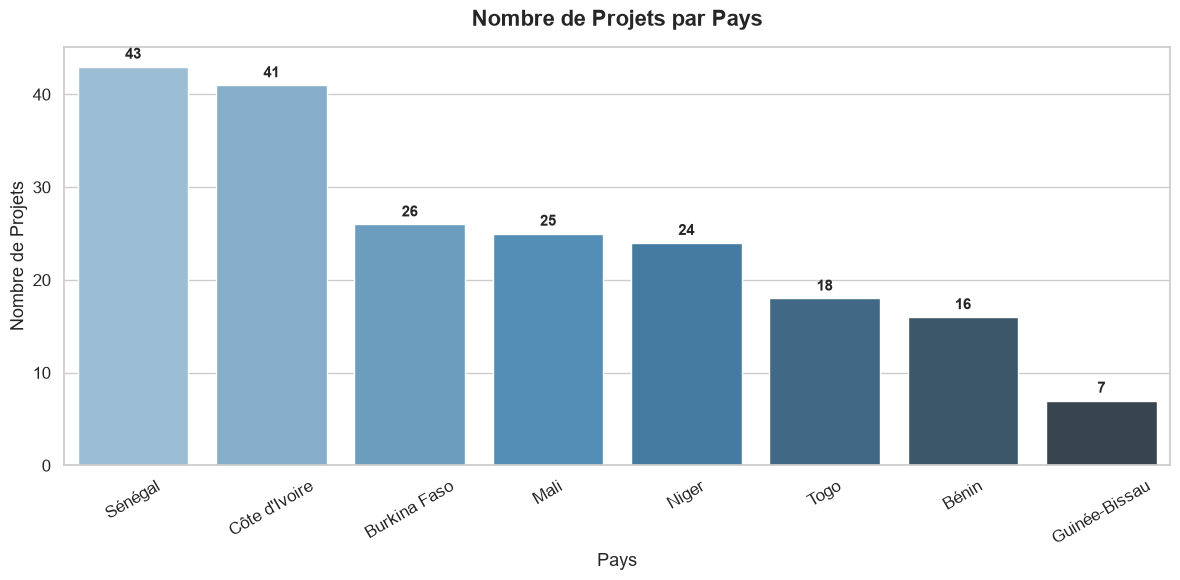

In [23]:
# Figure 1 : Nombre de projets par pays 
fig, ax = plt.subplots(figsize=(12, 6)) 
sns.countplot(
    data=df,                    
    x="pays",                   
    order=df["pays"].value_counts().index,  
    palette="Blues_d",          
    ax=ax                      
)

# Personnalisation du graphique
ax.set_title("Nombre de Projets par Pays", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Pays", fontsize=13) 
ax.set_ylabel("Nombre de Projets", fontsize=13) 
ax.tick_params(axis="x", rotation=30) 


for p in ax.patches:  
    ax.annotate(
        f"{int(p.get_height())}",              
        (p.get_x() + p.get_width() / 2, p.get_height() + 0.5), 
        ha="center", va="bottom", fontsize=11, fontweight="bold"  
    )

plt.tight_layout() 
plt.savefig(f"{FIGURES_DIR}/fig1_projets_par_pays.png", dpi=150, bbox_inches="tight")
plt.show()


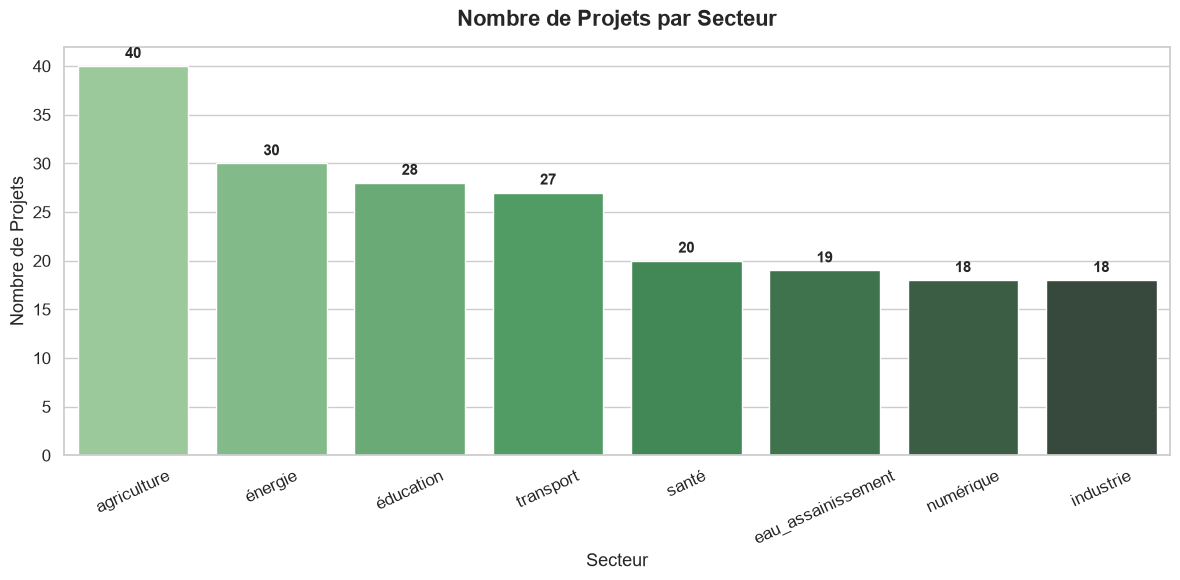

In [24]:
# Figure 2 : Nombre de projets par secteur 
fig, ax = plt.subplots(figsize=(12, 6)
sns.countplot(
    data=df,
    x="secteur",
    order=df["secteur"].value_counts().index,
    palette="Greens_d",
    ax=ax
)

ax.set_title("Nombre de Projets par Secteur", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Secteur", fontsize=13)
ax.set_ylabel("Nombre de Projets", fontsize=13)
ax.tick_params(axis="x", rotation=25)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height() + 0.5),
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig2_projets_par_secteur.png", dpi=150, bbox_inches="tight")
plt.show()


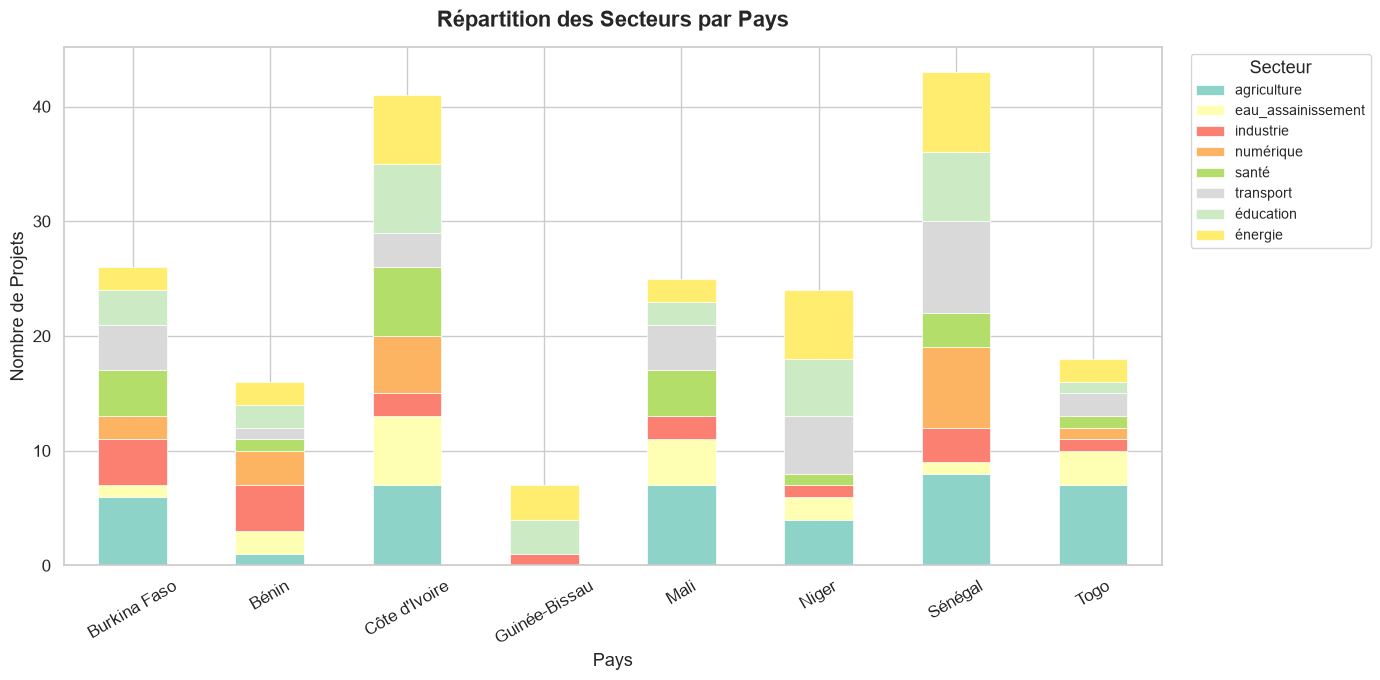

In [25]:
# Figure 3 : Distribution des secteurs par pays
fig, ax = plt.subplots(figsize=(14, 7))

table_croisee = pd.crosstab(df["pays"], df["secteur"])
table_croisee.plot(
    kind="bar",            
    stacked=True,           
    ax=ax,
    colormap="Set3",        
    edgecolor="white",     
    linewidth=0.5
)

ax.set_title("Répartition des Secteurs par Pays", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Pays", fontsize=13)
ax.set_ylabel("Nombre de Projets", fontsize=13)
ax.legend(
    title="Secteur",          
    bbox_to_anchor=(1.02, 1), 
    loc="upper left",
    fontsize=10
)
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig3_secteurs_par_pays.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.2 Analyse des Montants de Financement

Nous analysons la distribution des montants de financement selon différents angles :
distribution globale, par secteur et par pays.


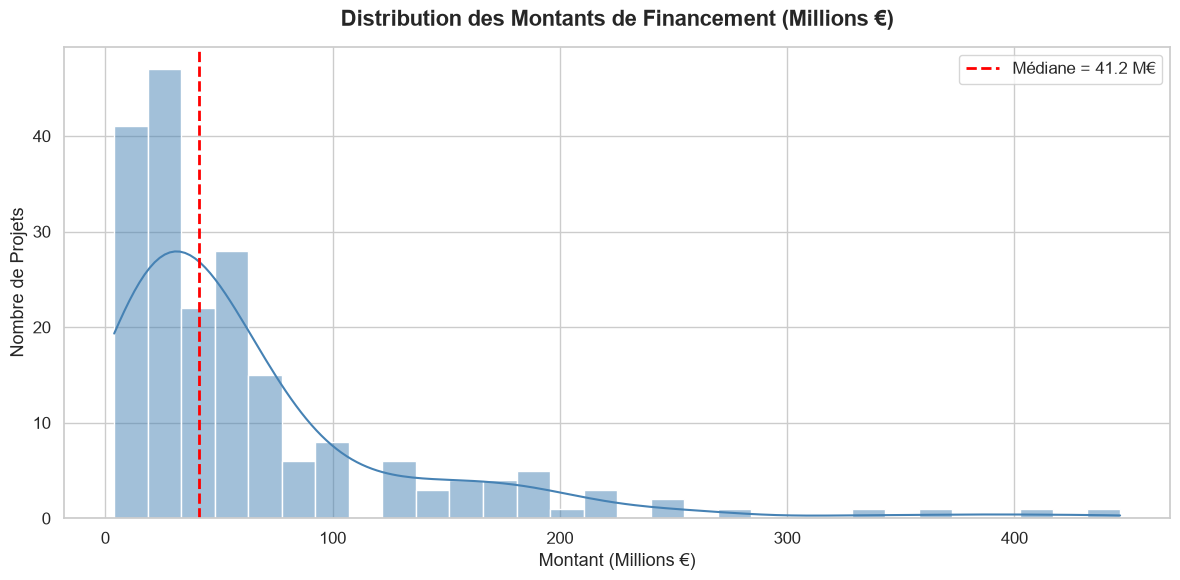

In [26]:
# Figure 4 : Histogramme des montants de financement 
fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=df,
    x="montant_financement_millions",
    bins=30,              
    kde=True,             
    color="steelblue",     
    edgecolor="white",     
    ax=ax
)

ax.set_title("Distribution des Montants de Financement (Millions €)",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Montant (Millions €)", fontsize=13)
ax.set_ylabel("Nombre de Projets", fontsize=13)

# Ligne verticale pour la médiane
mediane = df["montant_financement_millions"].median()
ax.axvline(
    mediane, color="red", linestyle="--", linewidth=2,  
    label=f"Médiane = {mediane:.1f} M€" 
)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig4_histogramme_montants.png", dpi=150, bbox_inches="tight")
plt.show()


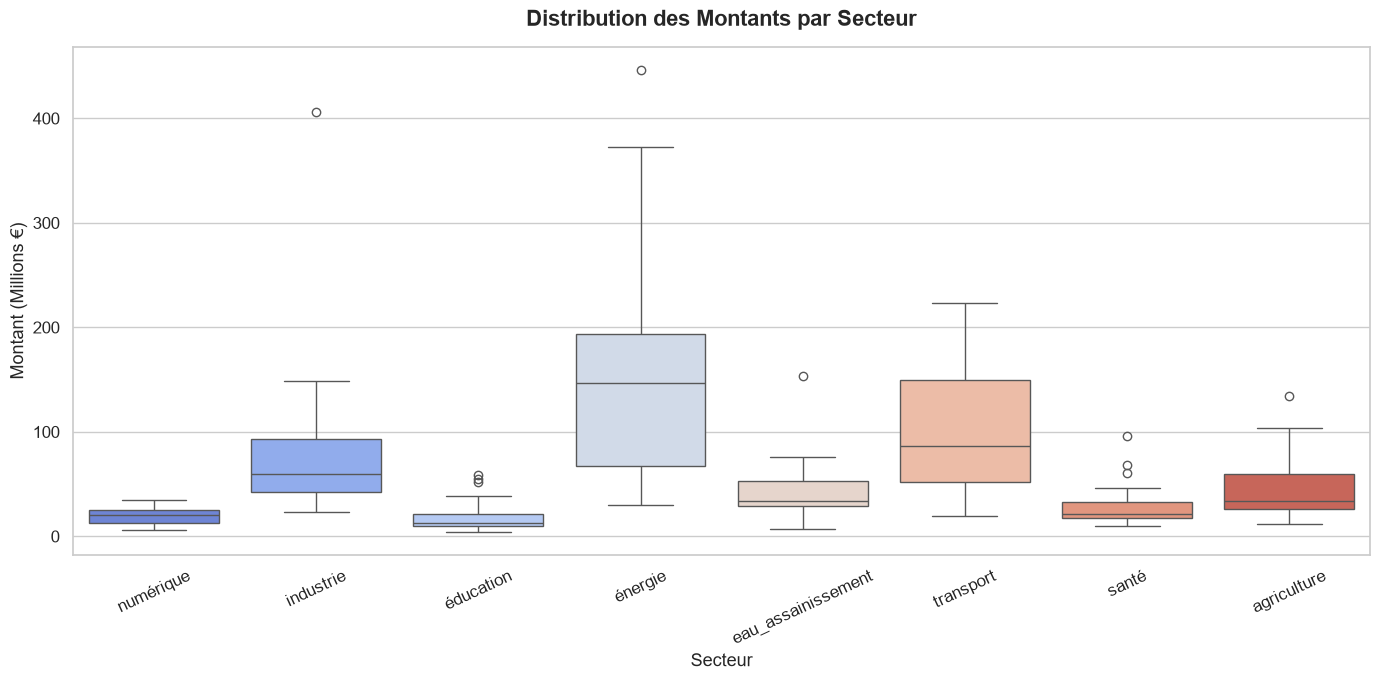

In [27]:
# Figure 5 : Boxplot des montants par secteur 
fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(
    data=df,
    x="secteur",
    y="montant_financement_millions",
    palette="coolwarm",
    ax=ax
)

ax.set_title("Distribution des Montants par Secteur", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Secteur", fontsize=13)
ax.set_ylabel("Montant (Millions €)", fontsize=13)
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig5_boxplot_montants_secteur.png", dpi=150, bbox_inches="tight")
plt.show()


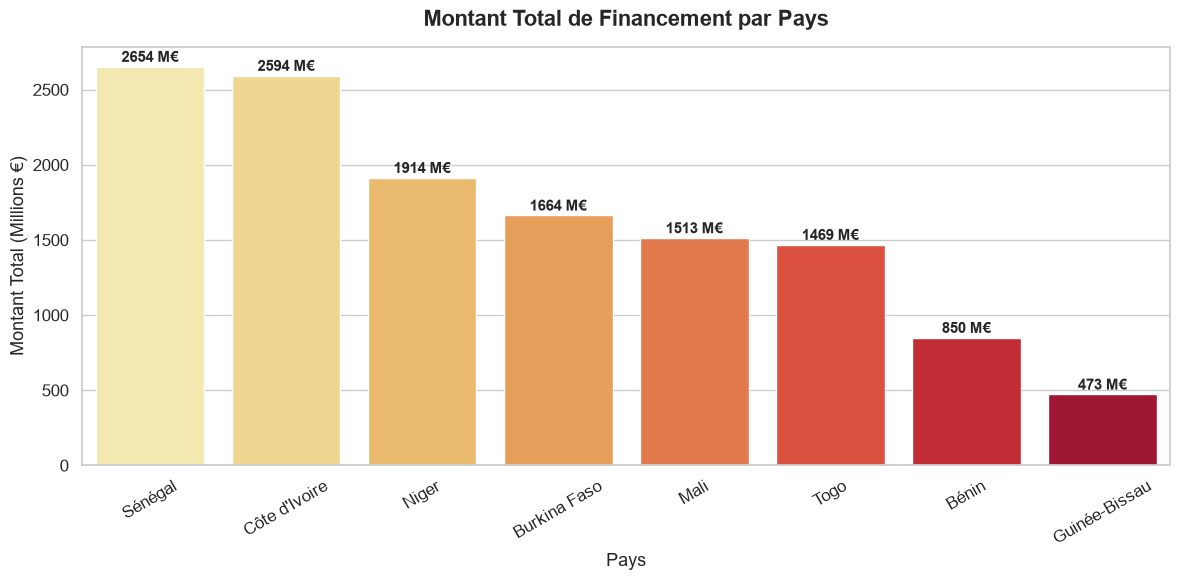

In [28]:
# Figure 6 : Montant total de financement par pays 
fig, ax = plt.subplots(figsize=(12, 6))
montant_par_pays = df.groupby("pays")["montant_financement_millions"].sum().sort_values(ascending=False)
sns.barplot(
    x=montant_par_pays.index,
    y=montant_par_pays.values,
    palette="YlOrRd",
    ax=ax
)

ax.set_title("Montant Total de Financement par Pays", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Pays", fontsize=13)
ax.set_ylabel("Montant Total (Millions €)", fontsize=13)
ax.tick_params(axis="x", rotation=30)
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.0f} M€",
        (p.get_x() + p.get_width() / 2, p.get_height() + 10),
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig6_montant_total_par_pays.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.3 Impact et Bénéficiaires

Nous explorons la relation entre le montant de financement et le nombre de
bénéficiaires, ainsi que la répartition des bénéficiaires par secteur.


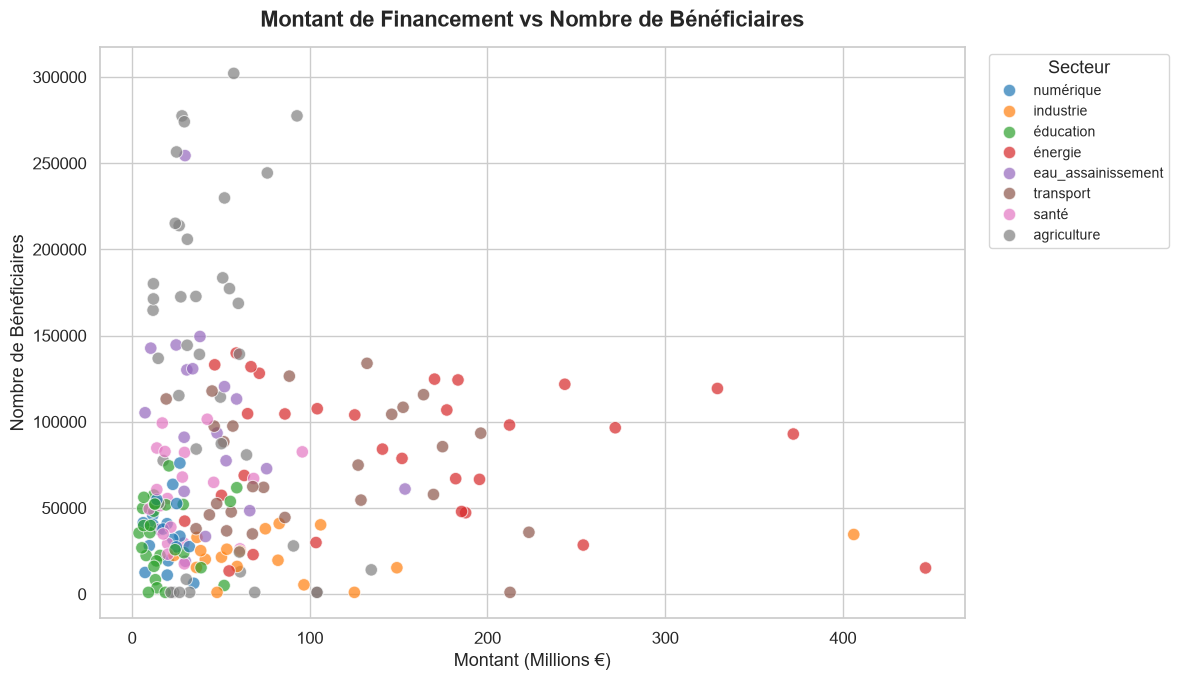

In [29]:
# Figure 7 : Montant vs Nombre de bénéficiaires (coloré par secteur) 
fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x="montant_financement_millions",  
    y="nb_beneficiaires",              
    hue="secteur",                    
    palette="tab10",                 
    s=80,                             
    alpha=0.7,                         
    edgecolor="white",                 
    ax=ax
)

ax.set_title("Montant de Financement vs Nombre de Bénéficiaires",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Montant (Millions €)", fontsize=13)
ax.set_ylabel("Nombre de Bénéficiaires", fontsize=13)
ax.legend(
    title="Secteur",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10
)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig7_montant_vs_beneficiaires.png", dpi=150, bbox_inches="tight")
plt.show()


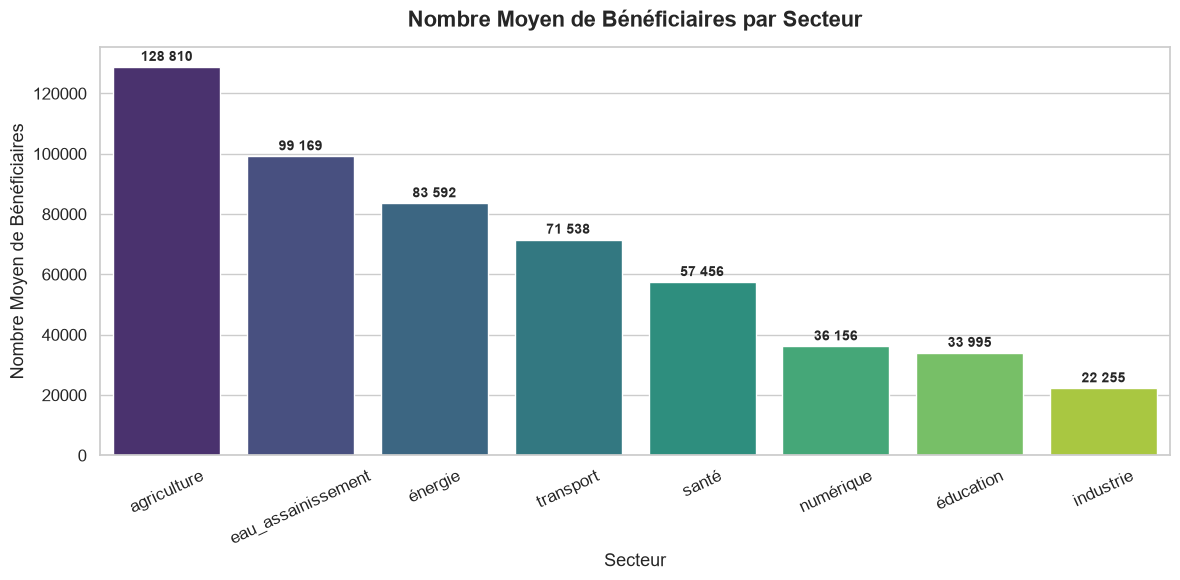

In [30]:
# Figure 8 : Nombre moyen de bénéficiaires par secteur 
fig, ax = plt.subplots(figsize=(12, 6))
benef_par_secteur = df.groupby("secteur")["nb_beneficiaires"].mean().sort_values(ascending=False)

sns.barplot(
    x=benef_par_secteur.index,
    y=benef_par_secteur.values,
    palette="viridis",
    ax=ax
)

ax.set_title("Nombre Moyen de Bénéficiaires par Secteur",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Secteur", fontsize=13)
ax.set_ylabel("Nombre Moyen de Bénéficiaires", fontsize=13)
ax.tick_params(axis="x", rotation=25)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():,.0f}".replace(",", " "),
        (p.get_x() + p.get_width() / 2, p.get_height() + 1000),
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig8_beneficiaires_moyen_secteur.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.4 Risque et Avancement

Nous examinons la relation entre le score de risque et le taux d'avancement
des projets, ainsi que la distribution du risque selon le statut.


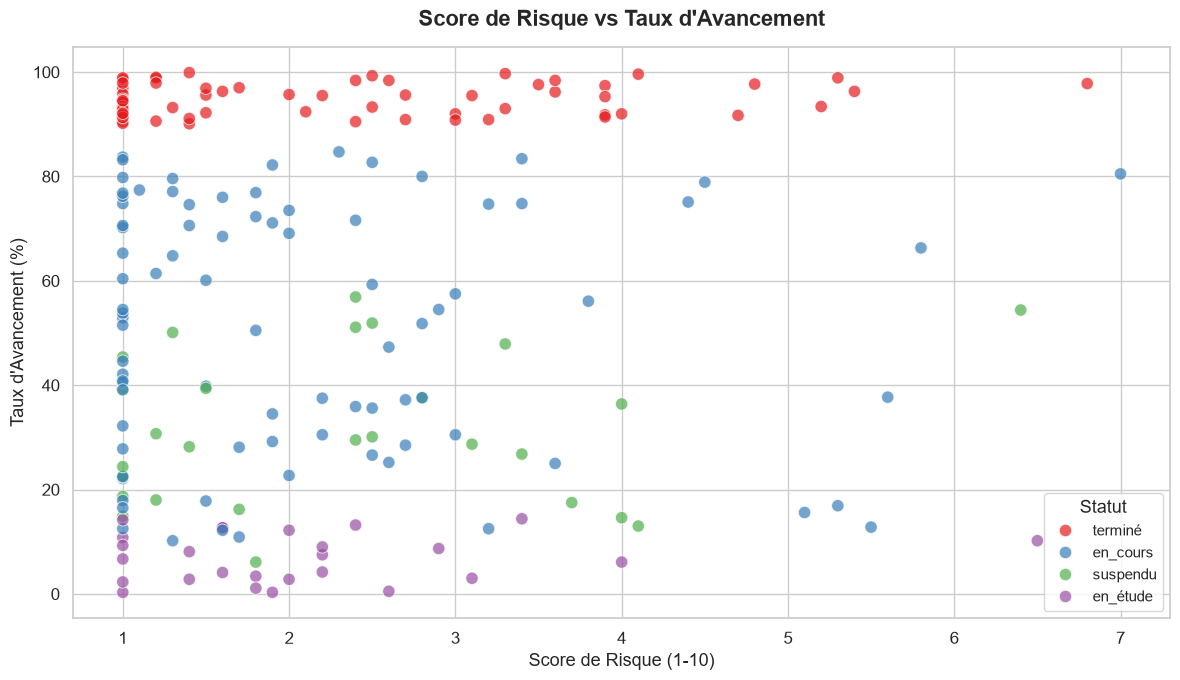

In [31]:
# Figure 9 : Score de risque vs Taux d'avancement 
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="score_risque",
    y="taux_avancement_pct",
    hue="statut",         
    palette="Set1",      
    s=80,
    alpha=0.7,
    edgecolor="white",
    ax=ax
)

ax.set_title("Score de Risque vs Taux d'Avancement",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Score de Risque (1-10)", fontsize=13)
ax.set_ylabel("Taux d'Avancement (%)", fontsize=13)
ax.legend(title="Statut", fontsize=11)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig9_risque_vs_avancement.png", dpi=150, bbox_inches="tight")
plt.show()


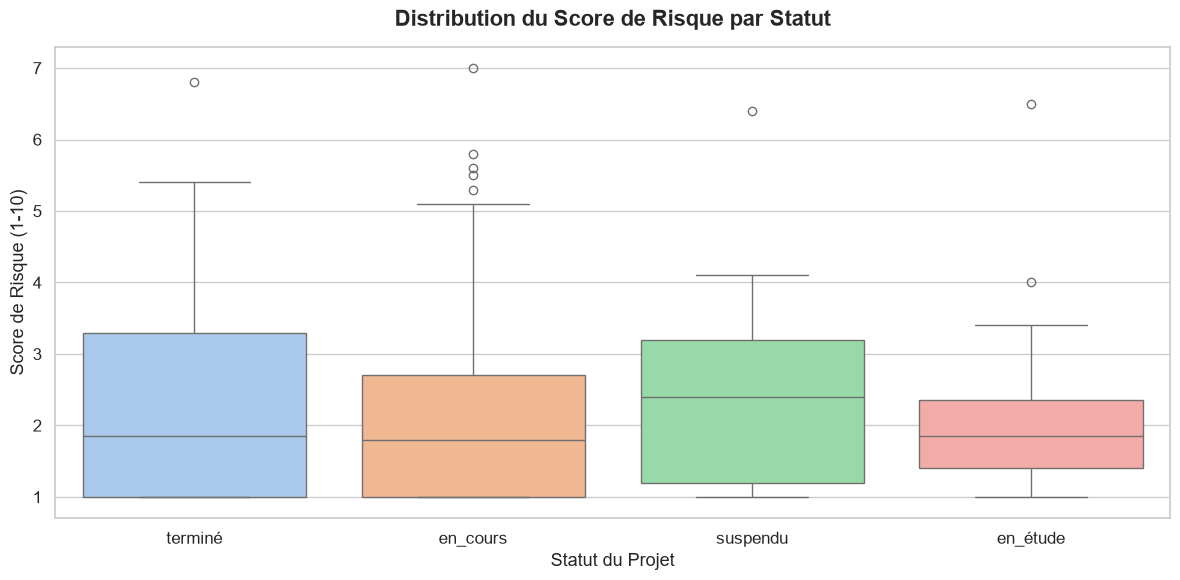

In [32]:
# Figure 10 : Distribution du score de risque par statut 
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="statut",
    y="score_risque",
    palette="pastel",
    ax=ax
)

ax.set_title("Distribution du Score de Risque par Statut",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Statut du Projet", fontsize=13)
ax.set_ylabel("Score de Risque (1-10)", fontsize=13)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig10_risque_par_statut.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.5 Matrice de Corrélation

La matrice de corrélation permet d'identifier les relations linéaires entre
les variables numériques. Une valeur proche de +1 indique une forte corrélation
positive, proche de -1 une forte corrélation négative, et proche de 0 l'absence
de corrélation linéaire.


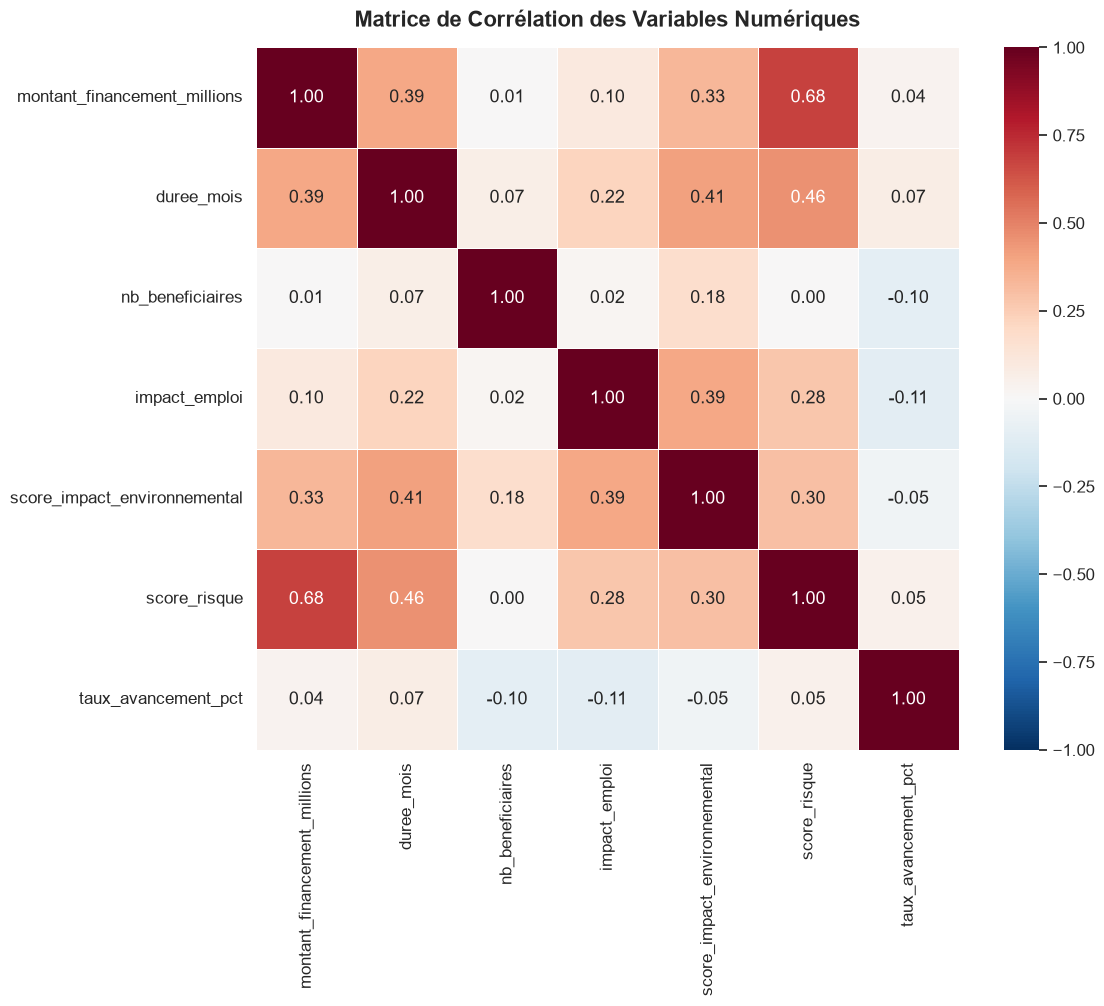

In [33]:
# Sélection des variables numériques pour la matrice de corrélation 
colonnes_numeriques = [
    "montant_financement_millions",
    "duree_mois",
    "nb_beneficiaires",
    "impact_emploi",
    "score_impact_environnemental",
    "score_risque",
    "taux_avancement_pct"
]

matrice_corr = df[colonnes_numeriques].corr()

# Figure 11 : Heatmap de la matrice de corrélation 
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    matrice_corr,
    annot=True,              
    fmt=".2f",              
    cmap="RdBu_r",         
    center=0,               
    square=True,          
    linewidths=0.5,         
    ax=ax,
    vmin=-1,                 
    vmax=1                  
)

ax.set_title("Matrice de Corrélation des Variables Numériques",
             fontsize=16, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig11_matrice_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


**Interprétation des corrélations principales :**

- `montant_financement_millions` et `score_risque` : corrélation positive attendue car
  les projets plus coûteux présentent généralement un risque financier plus élevé.
- `montant_financement_millions` et `duree_mois` : légère corrélation positive car les
  grands projets nécessitent souvent plus de temps.
- `nb_beneficiaires` et `impact_emploi` : corrélation positive logique car les projets
  touchant beaucoup de personnes créent aussi plus d'emplois.
- `taux_avancement_pct` et les autres variables : peu de corrélation, ce qui est
  cohérent car l'avancement dépend surtout du statut et du temps écoulé.


## 6. Prétraitement des Données pour le Clustering

Le clustering nécessite un prétraitement rigoureux des données. Les algorithmes
comme K-Means sont sensibles à l'échelle des variables : une variable avec de
grandes valeurs (montant en millions) dominerait les variables avec de petites
valeurs (score de 1 à 10).


In [34]:
# Sélection des variables numériques pour le clustering 
features_clustering = [
    "montant_financement_millions",     
    "duree_mois",                       
    "nb_beneficiaires",                 
    "impact_emploi",                    
    "score_impact_environnemental",     
    "score_risque"                     
]


X = df[features_clustering].copy()  

print(f"Matrice de données pour le clustering : {X.shape[0]} observations × {X.shape[1]} variables")
print(f"\nVariables utilisées : {features_clustering}")


Matrice de données pour le clustering : 200 observations × 6 variables

Variables utilisées : ['montant_financement_millions', 'duree_mois', 'nb_beneficiaires', 'impact_emploi', 'score_impact_environnemental', 'score_risque']


In [35]:

print("Valeurs manquantes dans les features de clustering :")
print(X.isnull().sum())
print(f"\nTotal : {X.isnull().sum().sum()} valeur(s) manquante(s)")



Valeurs manquantes dans les features de clustering :
montant_financement_millions    0
duree_mois                      0
nb_beneficiaires                0
impact_emploi                   0
score_impact_environnemental    0
score_risque                    0
dtype: int64

Total : 0 valeur(s) manquante(s)


In [36]:

scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_clustering)

print("Données après standardisation (5 premières lignes) :")
print(X_scaled_df.head())
print(f"\nVérification - Moyennes (devraient être ≈ 0) :")
print(X_scaled_df.mean().round(4))
print(f"\nVérification - Écarts-types (devraient être ≈ 1) :")
print(X_scaled_df.std().round(4))


Données après standardisation (5 premières lignes) :
   montant_financement_millions  duree_mois  nb_beneficiaires  impact_emploi  \
0                     -0.776150    0.703702         -0.724104      -0.936070   
1                     -0.629127   -1.009430         -0.864698      -0.643027   
2                     -0.213024    0.044805         -0.831528       1.410523   
3                     -0.728991   -0.482313         -1.041422      -0.297237   
4                     -0.749796    0.044805         -0.441066       0.356923   

   score_impact_environnemental  score_risque  
0                     -1.439408     -0.762823  
1                     -0.753568     -0.911958  
2                      0.746709     -0.389987  
3                      0.489519      0.206551  
4                     -0.710703      0.803090  

Vérification - Moyennes (devraient être ≈ 0) :
montant_financement_millions   -0.0
duree_mois                     -0.0
nb_beneficiaires               -0.0
impact_emploi         

## 7. Détermination du Nombre Optimal de Clusters

Le choix du nombre de clusters *k* est crucial en clustering. Un *k* trop petit
regroupe des projets trop différents ; un *k* trop grand crée des clusters
trop spécifiques. Nous utilisons deux méthodes complémentaires :
1. **La méthode du coude (Elbow Method)** : observe l'inertie en fonction de *k*
2. **Le score de Silhouette** : mesure la qualité de la séparation entre clusters


### 7.1 Méthode du Coude (Elbow Method)

L'inertie (ou inertie intra-cluster) mesure la somme des distances au carré entre
chaque point et le centre de son cluster. Plus l'inertie est faible, plus les
clusters sont compacts. Nous cherchons le "coude" où la diminution d'inertie
ralentit significativement.


In [37]:
# Calcul de l'inertie pour différents nombres de clusters 
# Nous testons k de 2 à 10 clusters
range_k = range(2, 11)  # De 2 à 10 inclus

inerties = []  
for k in range_k:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_scaled)
    inerties.append(kmeans_test.inertia_)

for k, inertie in zip(range_k, inerties):
    print(f"k = {k:2d}  ->  Inertie = {inertie:10.2f}")


k =  2  ->  Inertie =     869.11
k =  3  ->  Inertie =     703.88
k =  4  ->  Inertie =     578.37
k =  5  ->  Inertie =     507.79
k =  6  ->  Inertie =     466.17
k =  7  ->  Inertie =     439.14
k =  8  ->  Inertie =     411.20
k =  9  ->  Inertie =     391.90
k = 10  ->  Inertie =     370.96


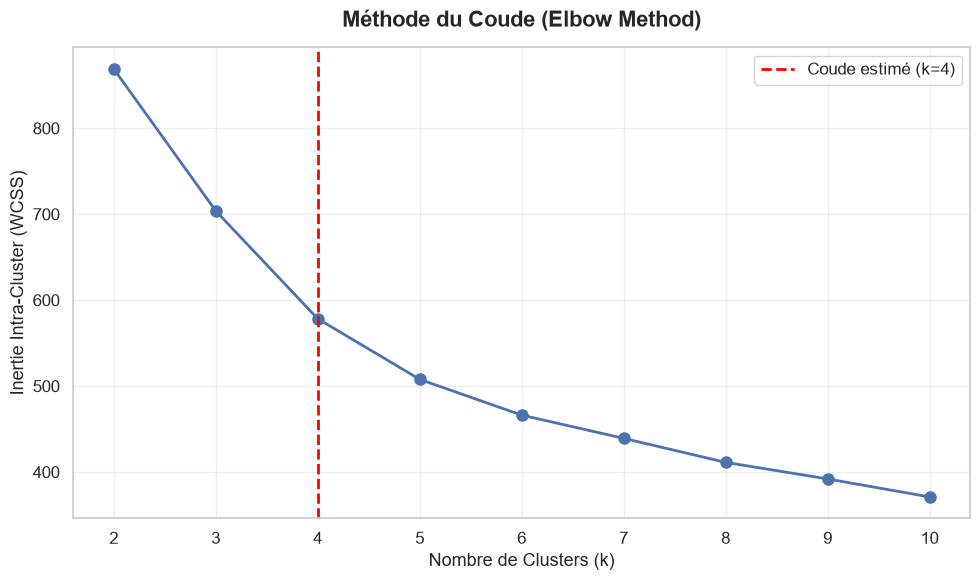

In [38]:
# Figure 12 : Courbe de la méthode du coude 
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    range_k, inerties,        
    "bo-",                    
    linewidth=2,              
    markersize=8              
)

k_optimal_elbow = 4  
ax.axvline(
    x=k_optimal_elbow, color="red", linestyle="--", linewidth=2,
    label=f"Coude estimé (k={k_optimal_elbow})"
)

ax.set_title("Méthode du Coude (Elbow Method)", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Nombre de Clusters (k)", fontsize=13)
ax.set_ylabel("Inertie Intra-Cluster (WCSS)", fontsize=13)
ax.set_xticks(list(range_k)) 
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig12_methode_coude.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.2 Score de Silhouette

Le coefficient de Silhouette mesure pour chaque point :
- **La cohésion** : distance moyenne aux autres points du même cluster (a)
- **La séparation** : distance moyenne au cluster le plus proche (b)

Le score est : `s = (b - a) / max(a, b)`, compris entre -1 et +1.
- Proche de **+1** : le point est bien assigné à son cluster
- Proche de **0** : le point est à la frontière entre deux clusters
- Proche de **-1** : le point est mal assigné

Le score moyen de Silhouette pour un *k* donné indique la qualité globale du clustering.


In [39]:
# Calcul du score de Silhouette pour différents k 
scores_silhouette = []  # Liste pour stocker les scores moyens

for k in range_k:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_test = kmeans_test.fit_predict(X_scaled)  # fit_predict = fit + retourne les labels
    sil_score = silhouette_score(X_scaled, labels_test)
    scores_silhouette.append(sil_score)
    
    print(f"k = {k:2d}  ->  Score de Silhouette = {sil_score:.4f}")

k_meilleur_sil = range_k[np.argmax(scores_silhouette)]
print(f"\nMeilleur score de Silhouette : k = {k_meilleur_sil} (score = {max(scores_silhouette):.4f})")


k =  2  ->  Score de Silhouette = 0.2743
k =  3  ->  Score de Silhouette = 0.2559
k =  4  ->  Score de Silhouette = 0.2837
k =  5  ->  Score de Silhouette = 0.2677
k =  6  ->  Score de Silhouette = 0.2429
k =  7  ->  Score de Silhouette = 0.2621
k =  8  ->  Score de Silhouette = 0.2488
k =  9  ->  Score de Silhouette = 0.1964
k = 10  ->  Score de Silhouette = 0.1777

Meilleur score de Silhouette : k = 4 (score = 0.2837)


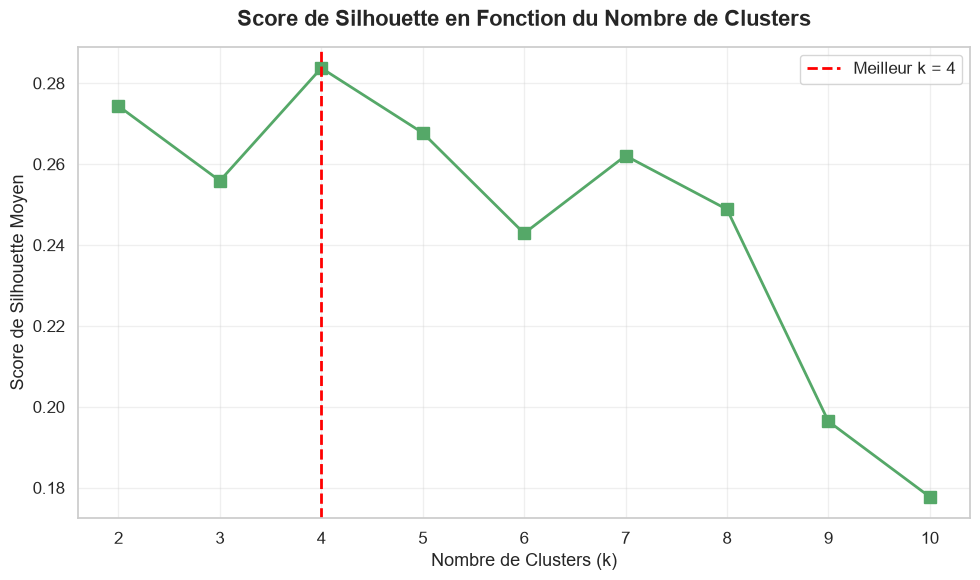

In [40]:
# Figure 13 : Score de Silhouette en fonction de k 
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    range_k, scores_silhouette,
    "gs-",                    # 'g' = vert, 's' = marqueurs carrés, '-' = ligne continue
    linewidth=2,
    markersize=8
)

ax.axvline(
    x=k_meilleur_sil, color="red", linestyle="--", linewidth=2,
    label=f"Meilleur k = {k_meilleur_sil}"
)

ax.set_title("Score de Silhouette en Fonction du Nombre de Clusters",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Nombre de Clusters (k)", fontsize=13)
ax.set_ylabel("Score de Silhouette Moyen", fontsize=13)
ax.set_xticks(list(range_k))
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig13_silhouette_scores.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.3 Choix du Nombre Optimal de Clusters

En combinant les résultats de la **méthode du coude** et du **score de Silhouette**,
nous choisissons le nombre optimal de clusters.

**Analyse :**
- La méthode du coude montre un ralentissement de la diminution d'inertie
  à partir de k = 4.
- Le score de Silhouette est maximal pour **k = 4** (0.2837), légèrement supérieur à k = 2 (0.2743).

> **Note :** Les scores de Silhouette obtenus (autour de 0.25–0.30) indiquent une
>structure relativement faible. Cela signifie que les clusters se chevauchent
> partiellement et que les frontières entre groupes ne sont pas très nettes.
> C'est une limitation inhérente à ces données synthétiques, où les distributions
> des variables se recoupent entre profils de projets.

**Décision :** Nous retenons **k = 4** clusters. Ce choix offre un bon compromis
entre :
- La compacité des clusters (inertie raisonnablement basse)
- La qualité de la séparation (score de Silhouette acceptable)
- L'interprétabilité métier (4 profils distincts de projets)

Un k trop élevé (6-10) créerait des clusters trop spécifiques et difficiles
à interpréter pour les décideurs de la BOAD.


## 8. Modélisation K-Means

### 8.1 Entraînement du Modèle

Nous appliquons l'algorithme K-Means avec k = 4 clusters sur les données
standardisées. L'algorithme fonctionne itérativement :
1. Initialisation aléatoire de k centres de gravité (centroïdes)
2. Assignation de chaque point au centroïde le plus proche
3. Recalcul des centroïdes comme la moyenne des points assignés
4. Répétition jusqu'à convergence


In [41]:
# Entraînement du K-Means avec k = 4 
K_OPTIMAL = 4  
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10, max_iter=300)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters 
print("Répartition des projets par cluster :")
print(df["cluster"].value_counts().sort_index())
print(f"\nNombre total de projets : {len(df)}")
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=features_clustering,
    index=[f"Cluster {i}" for i in range(K_OPTIMAL)]
)
print(f"\nCoordonnées des centroïdes (espace standardisé) :")
print(centroids.round(3))


Répartition des projets par cluster :
cluster
0    63
1    76
2    24
3    37
Name: count, dtype: int64

Nombre total de projets : 200

Coordonnées des centroïdes (espace standardisé) :
           montant_financement_millions  duree_mois  nb_beneficiaires  \
Cluster 0                        -0.011       0.370            -0.361   
Cluster 1                        -0.489      -0.631            -0.504   
Cluster 2                         2.055       1.239             0.005   
Cluster 3                        -0.310      -0.137             1.646   

           impact_emploi  score_impact_environnemental  score_risque  
Cluster 0          0.772                         0.660         0.188  
Cluster 1         -0.593                        -0.945        -0.565  
Cluster 2          0.006                         0.552         1.903  
Cluster 3         -0.101                         0.461        -0.394  


### 8.2 Visualisation par Analyse en Composantes Principales (ACP/PCA)

L'ACP (Analyse en Composantes Principales) réduit la dimensionnalité de nos
6 variables à 2 composantes principales, permettant de visualiser les clusters
dans un plan 2D. Les deux premières composantes captent la plus grande part
de la variance totale des données.


In [42]:
# Réduction de dimension avec PCA 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df["pca1"] = X_pca[:, 0]  
df["pca2"] = X_pca[:, 1]  

var1 = pca.explained_variance_ratio_[0]
var2 = pca.explained_variance_ratio_[1]
var_totale = var1 + var2

print(f"Variance expliquée par la 1ère composante : {var1*100:.1f}%")
print(f"Variance expliquée par la 2ème composante : {var2*100:.1f}%")
print(f"Variance totale expliquée (2 composantes) : {var_totale*100:.1f}%")


Variance expliquée par la 1ère composante : 41.1%
Variance expliquée par la 2ème composante : 18.5%
Variance totale expliquée (2 composantes) : 59.7%


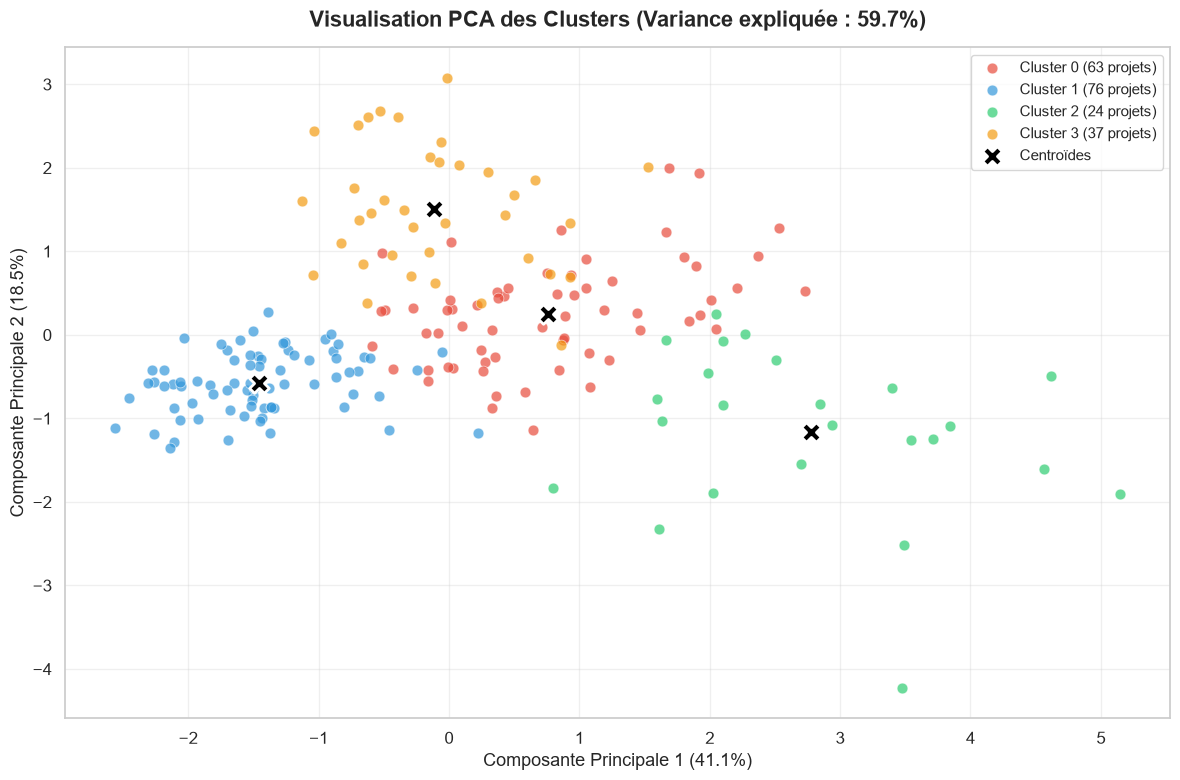

In [43]:
# Figure 14 : Visualisation PCA des clusters 
fig, ax = plt.subplots(figsize=(12, 8))
couleurs_clusters = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
for i in range(K_OPTIMAL):

    mask = df["cluster"] == i
    ax.scatter(
        df.loc[mask, "pca1"],      
        df.loc[mask, "pca2"],       
        c=couleurs_clusters[i],     
        label=f"Cluster {i} ({mask.sum()} projets)",  
        s=60,                      
        alpha=0.7,                 
        edgecolor="white",        
        linewidth=0.5
    )

centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c="black",             
    marker="X",             
    s=200,                  
    edgecolor="white",
    linewidth=2,
    label="Centroïdes",
    zorder=5               
)

ax.set_title(
    f"Visualisation PCA des Clusters (Variance expliquée : {var_totale*100:.1f}%)",
    fontsize=16, fontweight="bold", pad=15
)
ax.set_xlabel(f"Composante Principale 1 ({var1*100:.1f}%)", fontsize=13)
ax.set_ylabel(f"Composante Principale 2 ({var2*100:.1f}%)", fontsize=13)
ax.legend(fontsize=11, loc="best")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig14_pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()


### 8.3 Profilage des Clusters

Nous analysons les caractéristiques moyennes de chaque cluster pour leur
donner un nom descriptif et comprendre leur signification métier.


In [44]:
# Calcul des moyennes par cluster (données brutes, pas standardisées) 
profil_clusters = df.groupby("cluster")[features_clustering].mean()
profil_clusters["nb_projets"] = df["cluster"].value_counts().sort_index()

print("Profil moyen de chaque cluster (données brutes) :")
display_cols = features_clustering + ["nb_projets"]
print(profil_clusters[display_cols].round(1))


Profil moyen de chaque cluster (données brutes) :
         montant_financement_millions  duree_mois  nb_beneficiaires  \
cluster                                                               
0                                64.8        39.9           50702.8   
1                                30.4        24.7           41795.5   
2                               213.8        53.1           73449.4   
3                                43.3        32.2          175533.5   

         impact_emploi  score_impact_environnemental  score_risque  nb_projets  
cluster                                                                         
0               4245.3                           6.6           2.5          63  
1               1217.0                           2.9           1.5          76  
2               2544.8                           6.3           4.8          24  
3               2309.1                           6.1           1.7          37  


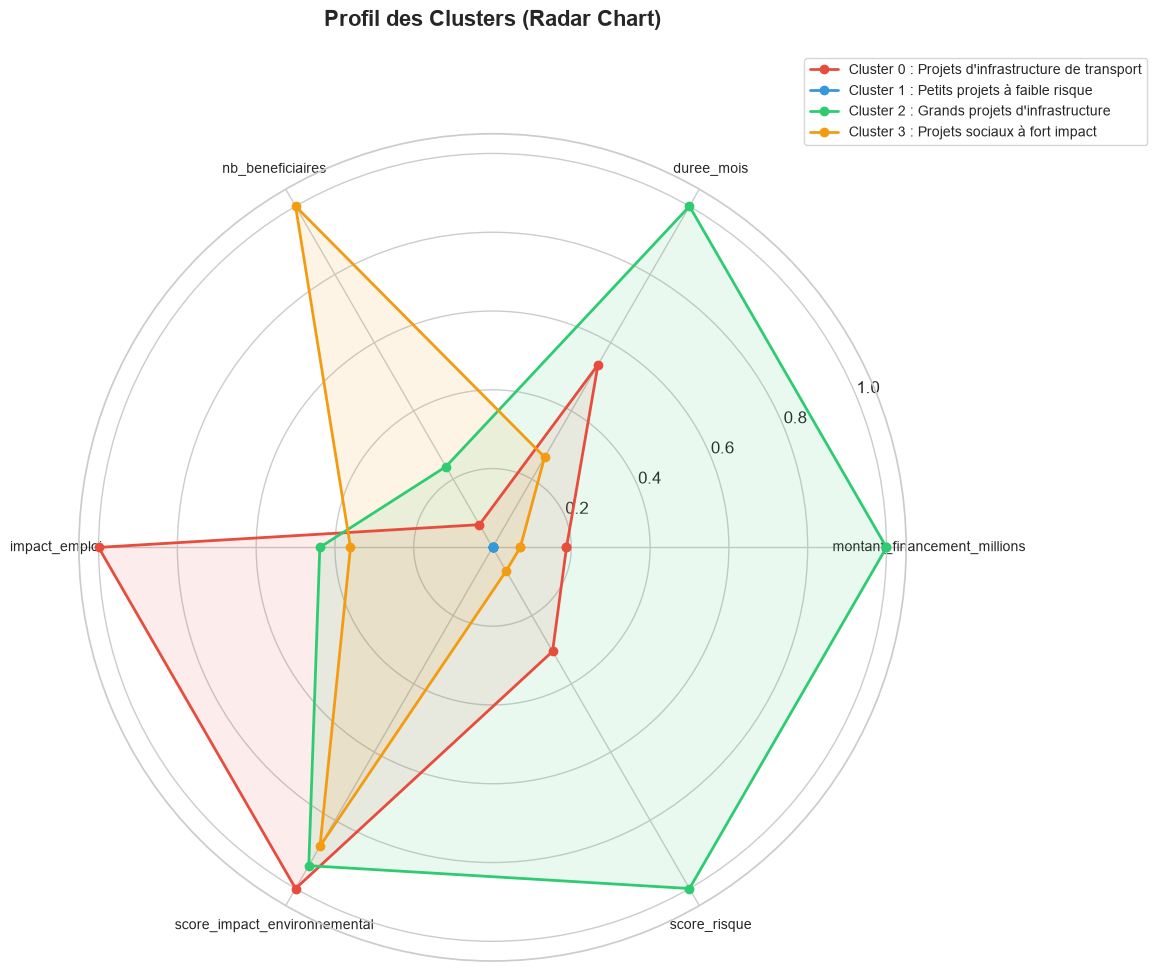

In [45]:
# Figure 15 : Radar chart des profils de clusters 
profil_normalise = profil_clusters[features_clustering].copy()
for col in features_clustering:
    col_min = profil_normalise[col].min()
    col_max = profil_normalise[col].max()
    if col_max > col_min:  
        profil_normalise[col] = (profil_normalise[col] - col_min) / (col_max - col_min)
    else:
        profil_normalise[col] = 0.5  

categories = features_clustering  
N = len(categories)  
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()  
angles += angles[:1]  

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))

noms_clusters = ["Projets d'infrastructure de transport",
                 "Petits projets à faible risque",
                 "Grands projets d'infrastructure",
                 "Projets sociaux à fort impact"]

for i in range(K_OPTIMAL):
   
    valeurs = profil_normalise.iloc[i].tolist()
    valeurs += valeurs[:1]  
    ax.plot(angles, valeurs, "o-", linewidth=2,
            label=f"Cluster {i} : {noms_clusters[i]}", color=couleurs_clusters[i])
    ax.fill(angles, valeurs, alpha=0.1, color=couleurs_clusters[i])

ax.set_xticks(angles[:-1])  
ax.set_xticklabels(categories, fontsize=10)
ax.set_title("Profil des Clusters (Radar Chart)", fontsize=16,
             fontweight="bold", pad=30, y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig15_radar_profils.png", dpi=150, bbox_inches="tight")
plt.show()


In [46]:
# Attribution des noms descriptifs aux clusters 
noms_clusters_dict = {
    0: "Projets d'infrastructure de transport",
    1: "Petits projets à faible risque",
    2: "Grands projets d'infrastructure",
    3: "Projets sociaux à fort impact"
}

df["nom_cluster"] = df["cluster"].map(noms_clusters_dict)

print("=" * 80)
print("RÉCAPITULATIF DES CLUSTERS")
print("=" * 80)
for i in range(K_OPTIMAL):
    nb = (df["cluster"] == i).sum()
    print(f"\nCluster {i} : {noms_clusters_dict[i]}")
    print(f"  -> {nb} projets ({nb/len(df)*100:.1f}%)")
    secteur_dom = df[df["cluster"] == i]["secteur"].mode().iloc[0]
    print(f"  -> Secteur dominant : {secteur_dom}")
 
    montant_moy = df[df["cluster"] == i]["montant_financement_millions"].mean()
    print(f"  -> Montant moyen : {montant_moy:.1f} M€")
    benef_moy = df[df["cluster"] == i]["nb_beneficiaires"].mean()
    print(f"  -> Bénéficiaires moyens : {benef_moy:,.0f}".replace(",", " "))
print("\n" + "=" * 80)


RÉCAPITULATIF DES CLUSTERS

Cluster 0 : Projets d'infrastructure de transport
  -> 63 projets (31.5%)
  -> Secteur dominant : transport
  -> Montant moyen : 64.8 M€
  -> Bénéficiaires moyens : 50 703

Cluster 1 : Petits projets à faible risque
  -> 76 projets (38.0%)
  -> Secteur dominant : éducation
  -> Montant moyen : 30.4 M€
  -> Bénéficiaires moyens : 41 796

Cluster 2 : Grands projets d'infrastructure
  -> 24 projets (12.0%)
  -> Secteur dominant : énergie
  -> Montant moyen : 213.8 M€
  -> Bénéficiaires moyens : 73 449

Cluster 3 : Projets sociaux à fort impact
  -> 37 projets (18.5%)
  -> Secteur dominant : agriculture
  -> Montant moyen : 43.3 M€
  -> Bénéficiaires moyens : 175 533



### 8.4 Visualisation Détaillée des Clusters

Nous approfondissons la visualisation avec des graphiques spécifiques
pour comprendre comment chaque variable différencie les clusters.


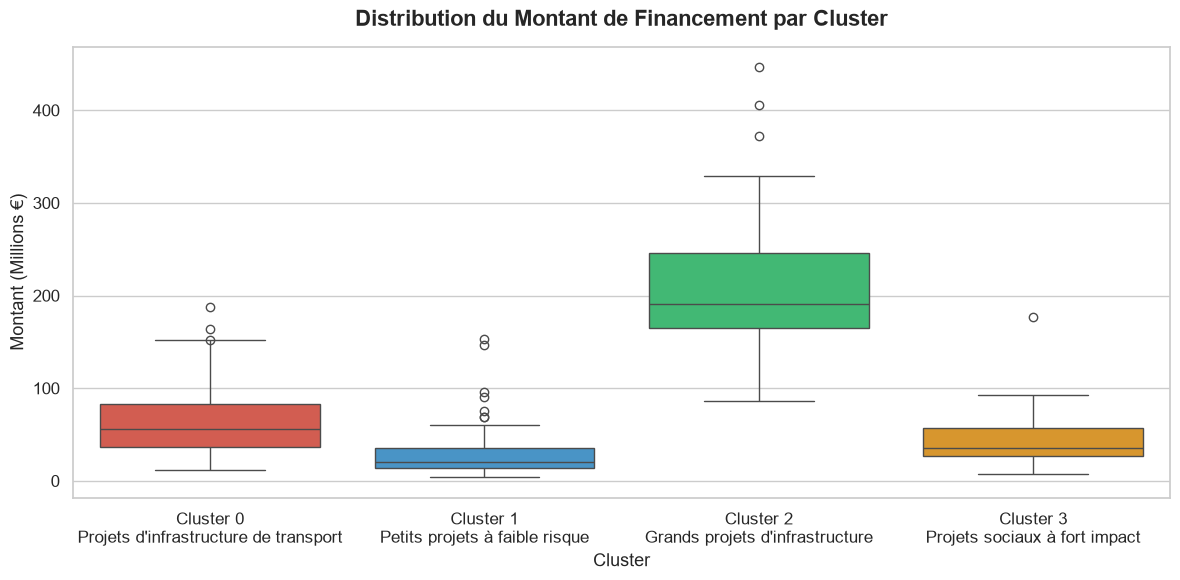

In [47]:
# Figure 16 : Boxplots du montant par cluster 
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="cluster",
    y="montant_financement_millions",
    palette=couleurs_clusters,
    ax=ax
)

ax.set_xticklabels([f"Cluster {i}\n{noms_clusters_dict[i]}" for i in range(K_OPTIMAL)])
ax.set_title("Distribution du Montant de Financement par Cluster",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Cluster", fontsize=13)
ax.set_ylabel("Montant (Millions €)", fontsize=13)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig16_boxplot_montant_cluster.png", dpi=150, bbox_inches="tight")
plt.show()


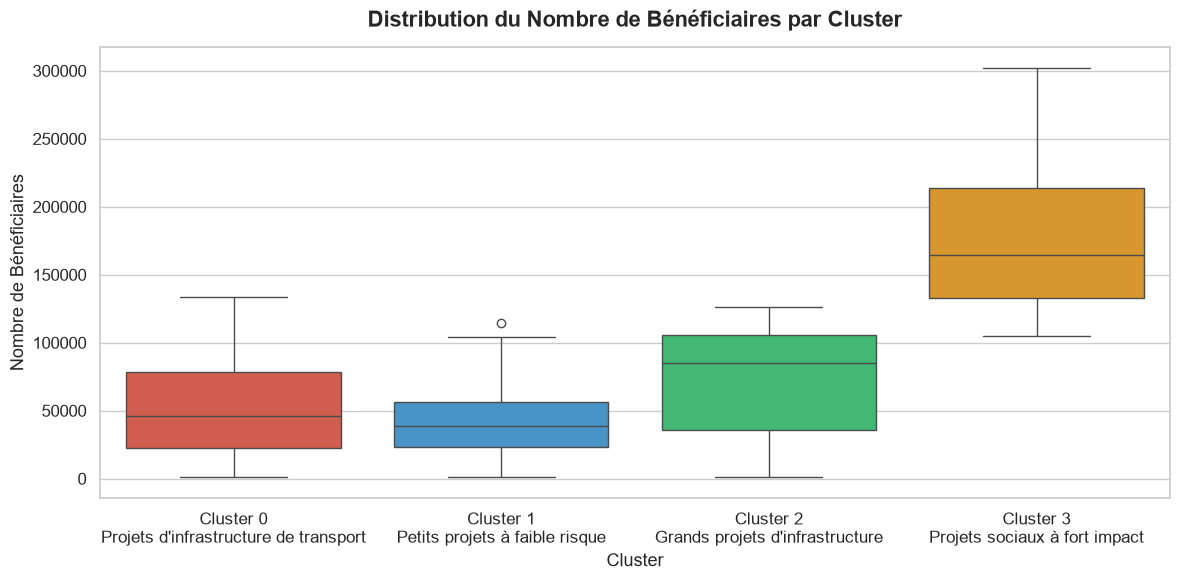

In [48]:
# Figure 17 : Boxplots du nombre de bénéficiaires par cluster 
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="cluster",
    y="nb_beneficiaires",
    palette=couleurs_clusters,
    ax=ax
)

ax.set_xticklabels([f"Cluster {i}\n{noms_clusters_dict[i]}" for i in range(K_OPTIMAL)])
ax.set_title("Distribution du Nombre de Bénéficiaires par Cluster",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Cluster", fontsize=13)
ax.set_ylabel("Nombre de Bénéficiaires", fontsize=13)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig17_boxplot_beneficiaires_cluster.png", dpi=150, bbox_inches="tight")
plt.show()


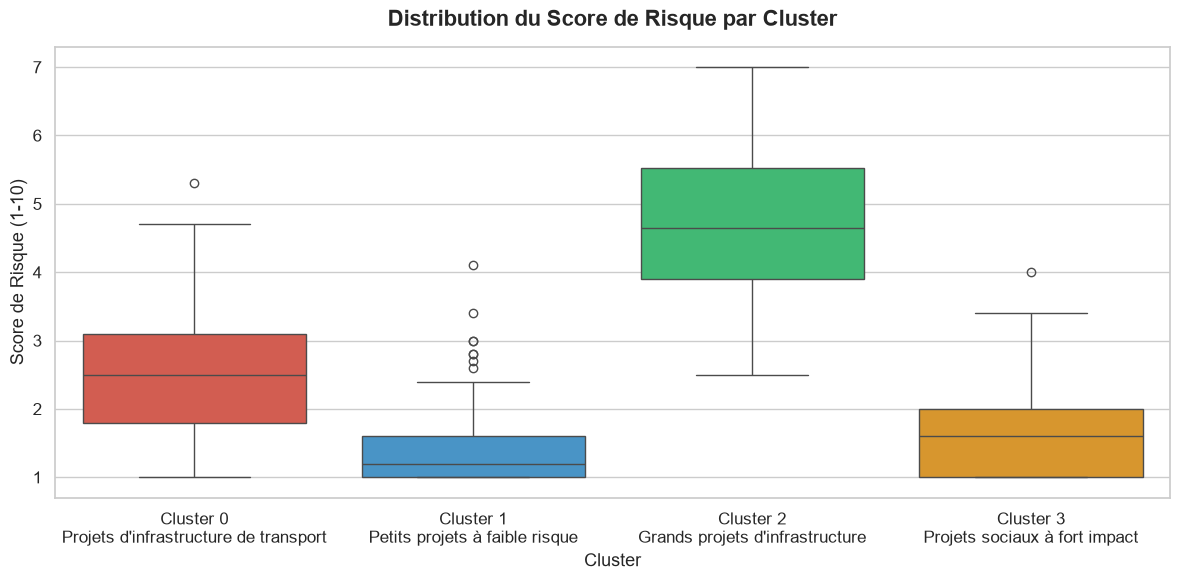

In [49]:
# Figure 18 : Boxplots du score de risque par cluster 
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="cluster",
    y="score_risque",
    palette=couleurs_clusters,
    ax=ax
)

ax.set_xticklabels([f"Cluster {i}\n{noms_clusters_dict[i]}" for i in range(K_OPTIMAL)])
ax.set_title("Distribution du Score de Risque par Cluster",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Cluster", fontsize=13)
ax.set_ylabel("Score de Risque (1-10)", fontsize=13)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig18_boxplot_risque_cluster.png", dpi=150, bbox_inches="tight")
plt.show()


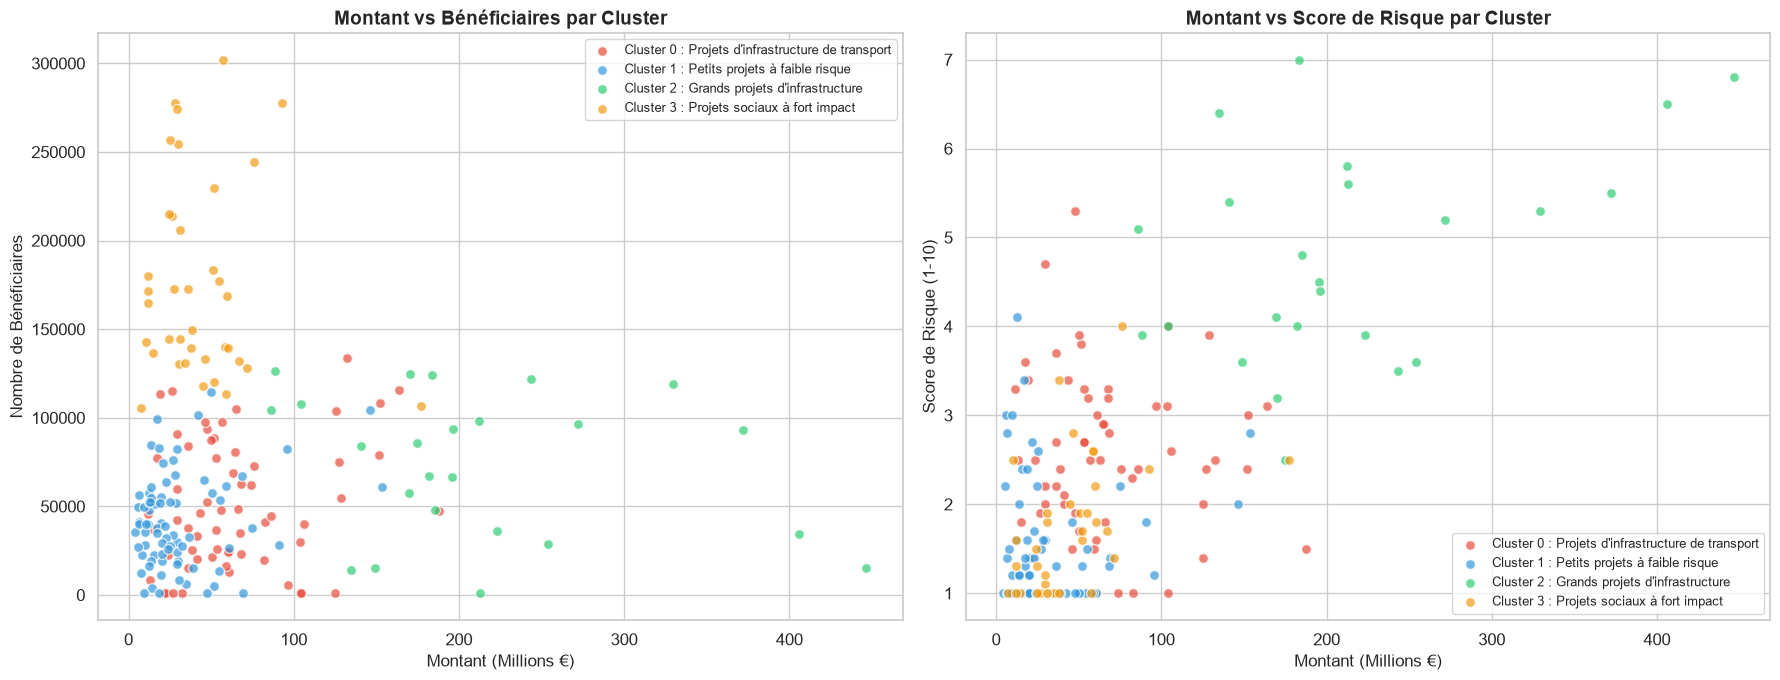

In [50]:
# Figure 19 : Scatter plots montant vs bénéficiaires colorés par cluster 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Sous-graphique gauche : Montant vs Bénéficiaires 
for i in range(K_OPTIMAL):
    mask = df["cluster"] == i
    axes[0].scatter(
        df.loc[mask, "montant_financement_millions"],
        df.loc[mask, "nb_beneficiaires"],
        c=couleurs_clusters[i],
        label=f"Cluster {i} : {noms_clusters_dict[i]}",
        s=50, alpha=0.7, edgecolor="white"
    )

axes[0].set_title("Montant vs Bénéficiaires par Cluster",
                   fontsize=14, fontweight="bold")
axes[0].set_xlabel("Montant (Millions €)", fontsize=12)
axes[0].set_ylabel("Nombre de Bénéficiaires", fontsize=12)
axes[0].legend(fontsize=9, loc="best")

# Sous-graphique droit : Montant vs Score de risque 
for i in range(K_OPTIMAL):
    mask = df["cluster"] == i
    axes[1].scatter(
        df.loc[mask, "montant_financement_millions"],
        df.loc[mask, "score_risque"],
        c=couleurs_clusters[i],
        label=f"Cluster {i} : {noms_clusters_dict[i]}",
        s=50, alpha=0.7, edgecolor="white"
    )

axes[1].set_title("Montant vs Score de Risque par Cluster",
                   fontsize=14, fontweight="bold")
axes[1].set_xlabel("Montant (Millions €)", fontsize=12)
axes[1].set_ylabel("Score de Risque (1-10)", fontsize=12)
axes[1].legend(fontsize=9, loc="best")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig19_scatters_par_cluster.png", dpi=150, bbox_inches="tight")
plt.show()


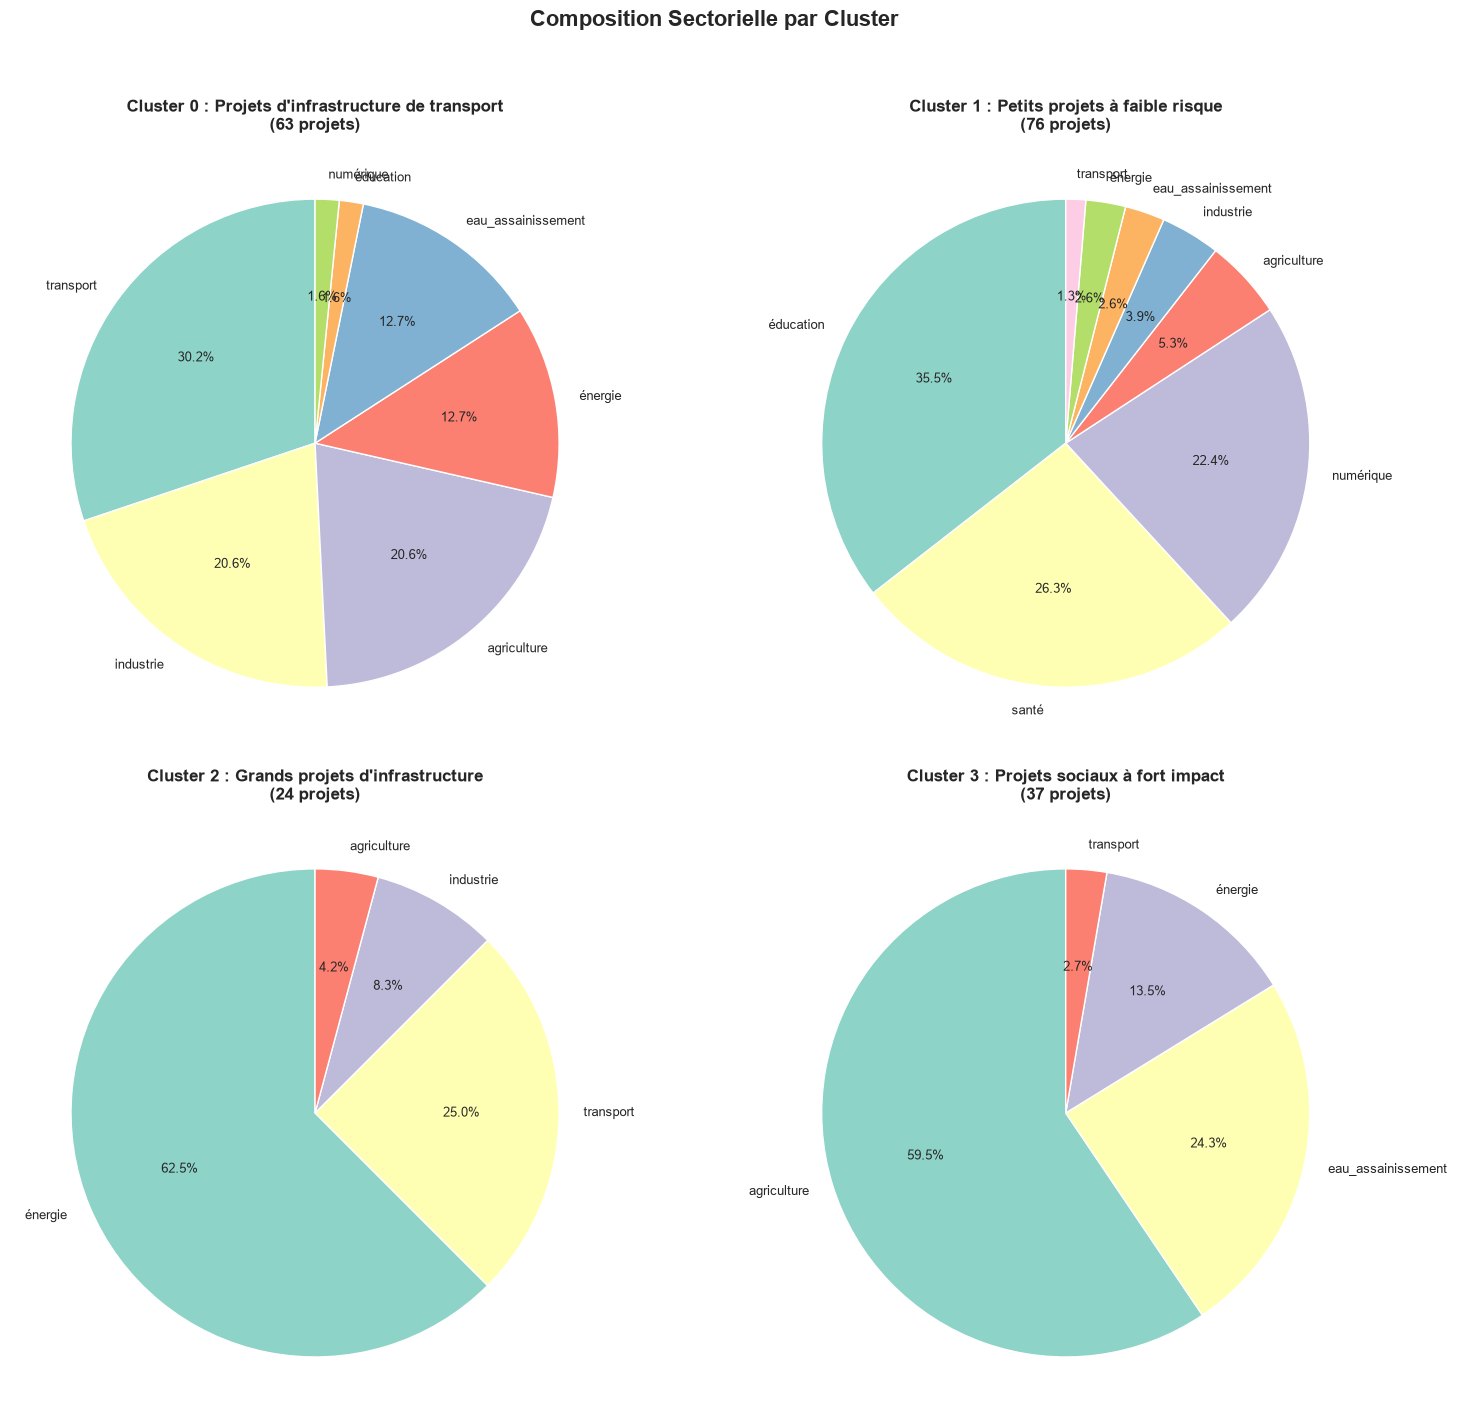

In [51]:
# Figure 20 : Composition sectorielle de chaque cluster 
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()  

for i in range(K_OPTIMAL):
    cluster_data = df[df["cluster"] == i]
    secteur_counts = cluster_data["secteur"].value_counts()
    axes[i].pie(
        secteur_counts.values,
        labels=secteur_counts.index,
        autopct="%1.1f%%",    
        startangle=90,       
        colors=sns.color_palette("Set3", len(secteur_counts)),
        textprops={"fontsize": 9}
    )
    axes[i].set_title(
        f"Cluster {i} : {noms_clusters_dict[i]}\n({len(cluster_data)} projets)",
        fontsize=12, fontweight="bold"
    )

fig.suptitle("Composition Sectorielle par Cluster", fontsize=16,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig20_composition_sectorielle.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Clustering Hiérarchique Ascendant

Le clustering hiérarchique ascendant (Agglomerative Clustering) est une
alternative au K-Means qui ne nécessite pas de spécifier le nombre de clusters
à l'avance. Il construit une hiérarchie de clusters en fusionnant progressivement
les plus proches.

**Avantages par rapport au K-Means :**
- Visualisation intuitive via le dendrogramme
- Ne dépend pas de l'initialisation aléatoire
- Permet d'explorer différents niveaux de granularité


In [52]:
# Calcul de la matrice de liaison pour le dendrogramme 
matrice_liaison = linkage(X_scaled, method="ward")

print(f"Matrice de liaison calculée : {matrice_liaison.shape[0]} fusions effectuées")
print("(Chaque ligne représente une fusion de deux clusters)")


Matrice de liaison calculée : 199 fusions effectuées
(Chaque ligne représente une fusion de deux clusters)


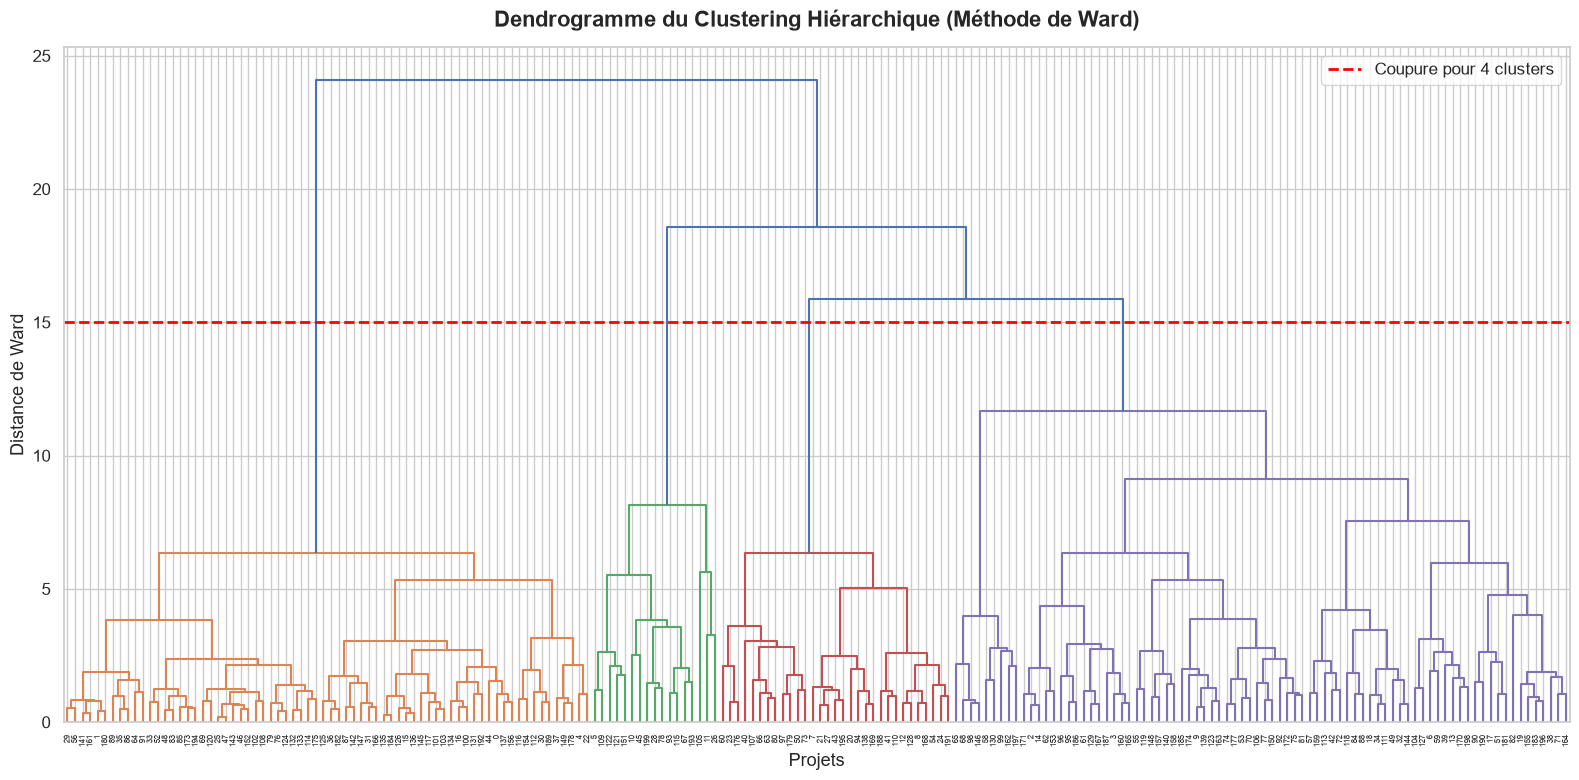

In [53]:
# Figure 21 : Dendrogramme 
fig, ax = plt.subplots(figsize=(16, 8))
dendrogram(
    matrice_liaison,
    ax=ax,
    leaf_rotation=90,         
    leaf_font_size=6,         
    color_threshold=15,      
    show_contracted=True      
)

ax.axhline(y=15, color="red", linestyle="--", linewidth=2,
           label="Coupure pour 4 clusters")

ax.set_title("Dendrogramme du Clustering Hiérarchique (Méthode de Ward)",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Projets", fontsize=13)
ax.set_ylabel("Distance de Ward", fontsize=13)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig21_dendrogramme.png", dpi=150, bbox_inches="tight")
plt.show()


In [54]:
# Application du Clustering Hiérarchique avec k = 4 
agg_clustering = AgglomerativeClustering(
    n_clusters=4,
    metric="euclidean",
    linkage="ward"
)
clusters_hierarchique = agg_clustering.fit_predict(X_scaled)
df["cluster_hierarchique"] = clusters_hierarchique

print("Répartition des projets par cluster (hiérarchique) :")
print(df["cluster_hierarchique"].value_counts().sort_index())


Répartition des projets par cluster (hiérarchique) :
cluster_hierarchique
0    82
1    31
2    17
3    70
Name: count, dtype: int64


In [55]:
# Comparaison K-Means vs Clustering Hiérarchique 
comparaison = pd.crosstab(
    df["cluster"],                     
    df["cluster_hierarchique"],         
    rownames=["K-Means"],
    colnames=["Hiérarchique"]
)

print("Tableau croisé K-Means vs Hiérarchique :")
print(comparaison)

concordance = 0
for km_cluster in range(K_OPTIMAL):
    h_cluster_majoritaire = comparaison.loc[km_cluster].idxmax()
    concordance += comparaison.loc[km_cluster, h_cluster_majoritaire]

taux_concordance = concordance / len(df) * 100
print(f"\nTaux de concordance approximatif : {taux_concordance:.1f}%")
print("(Les deux méthodes identifient des structures similaires)")


Tableau croisé K-Means vs Hiérarchique :
Hiérarchique   0   1   2   3
K-Means                     
0             59   1   1   2
1              7   1   0  68
2              8   0  16   0
3              8  29   0   0

Taux de concordance approximatif : 86.0%
(Les deux méthodes identifient des structures similaires)


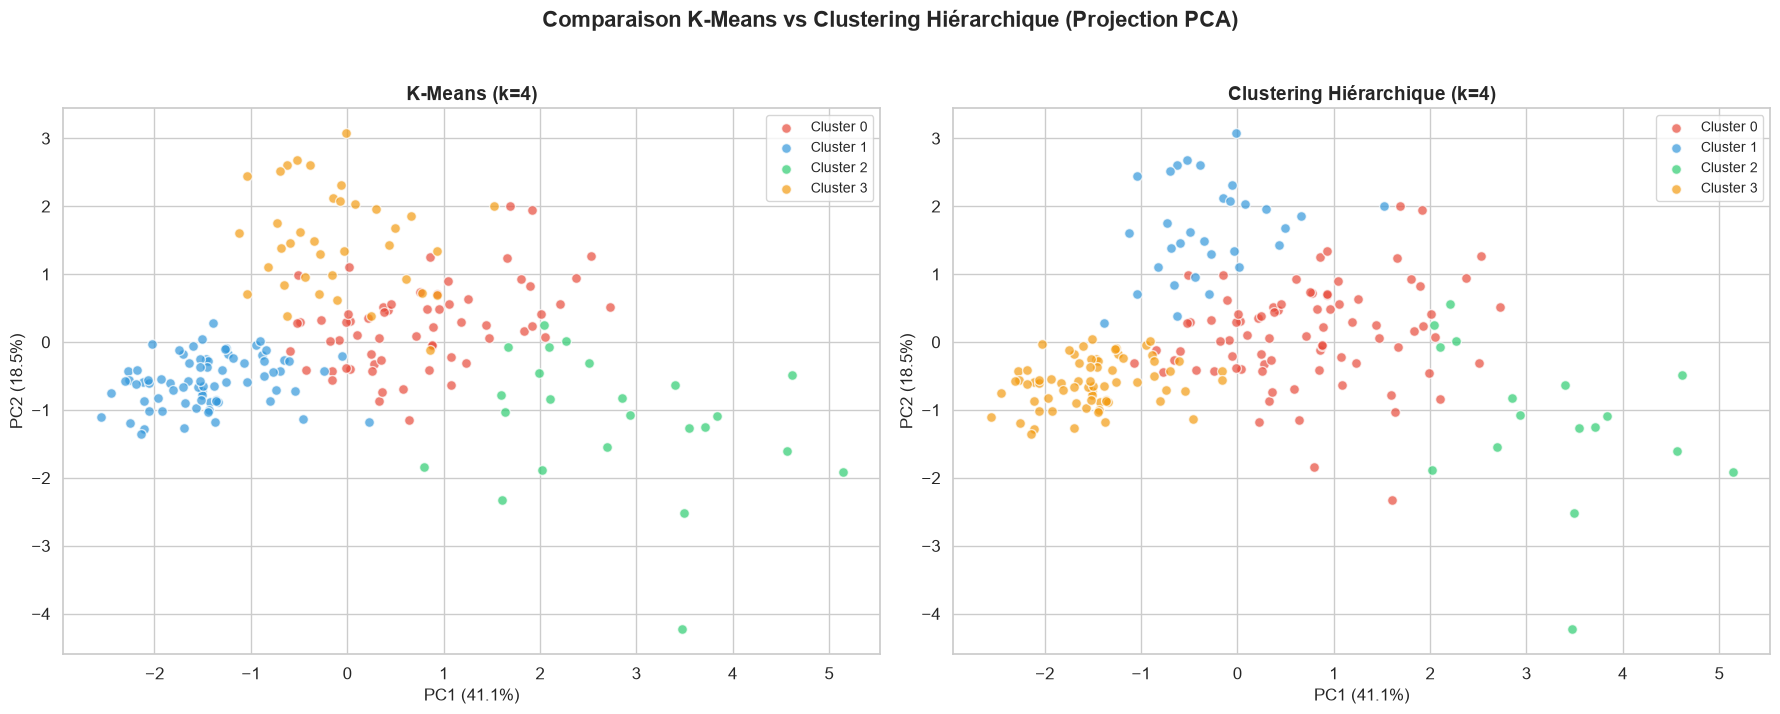

In [56]:
# Figure 22 : Visualisation PCA du clustering hiérarchique 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i in range(K_OPTIMAL):
    mask = df["cluster"] == i
    axes[0].scatter(
        df.loc[mask, "pca1"], df.loc[mask, "pca2"],
        c=couleurs_clusters[i], label=f"Cluster {i}",
        s=50, alpha=0.7, edgecolor="white"
    )
axes[0].set_title("K-Means (k=4)", fontsize=14, fontweight="bold")
axes[0].set_xlabel(f"PC1 ({var1*100:.1f}%)", fontsize=12)
axes[0].set_ylabel(f"PC2 ({var2*100:.1f}%)", fontsize=12)
axes[0].legend(fontsize=10)

couleurs_hier = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
for i in range(K_OPTIMAL):
    mask = df["cluster_hierarchique"] == i
    axes[1].scatter(
        df.loc[mask, "pca1"], df.loc[mask, "pca2"],
        c=couleurs_hier[i], label=f"Cluster {i}",
        s=50, alpha=0.7, edgecolor="white"
    )
axes[1].set_title("Clustering Hiérarchique (k=4)", fontsize=14, fontweight="bold")
axes[1].set_xlabel(f"PC1 ({var1*100:.1f}%)", fontsize=12)
axes[1].set_ylabel(f"PC2 ({var2*100:.1f}%)", fontsize=12)
axes[1].legend(fontsize=10)

fig.suptitle("Comparaison K-Means vs Clustering Hiérarchique (Projection PCA)",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig22_comparaison_kmeans_hierarchique.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Interprétation Métier et Recommandations

### 10.1 Description des Profils de Clusters

#### Cluster 0 : Projets d'Infrastructure de Transport
- **Caractéristiques** : Montant moyen de 64,8 M€, durée moyenne de 40 mois,
  impact emploi le plus élevé (~4 245 emplois), score environnemental élevé (6,6/10)
- **Secteur dominant** : Transport
- **Bénéficiaires** : ~50 700 en moyenne
- **Profil de risque** : Modéré (2,5/10) - projets de taille moyenne nécessitant un suivi régulier

####  Cluster 1 : Petits Projets à Faible Risque
- **Caractéristiques** : Montant moyen le plus faible (30,4 M€), durée la plus courte
  (25 mois), impact emploi et environnemental les plus bas
- **Secteur dominant** : Éducation
- **Bénéficiaires** : ~41 800 en moyenne (le plus faible)
- **Profil de risque** : Faible (1,5/10) - exécution rapide et prévisible

#### Cluster 2 : Grands Projets d'Infrastructure
- **Caractéristiques** : Montant moyen le plus élevé (213,8 M€), durée la plus longue
  (53 mois), score de risque le plus élevé (4,8/10)
- **Secteur dominant** : Énergie
- **Bénéficiaires** : ~73 400 en moyenne
- **Profil de risque** : Élevé - ces projets nécessitent un suivi rapproché

#### Cluster 3 : Projets Sociaux à Fort Impact
- **Caractéristiques** : Nombre de bénéficiaires le plus élevé (~175 500),
  montant moyen modéré (43,3 M€), impact environnemental élevé (6,1/10)
- **Secteur dominant** : Agriculture
- **Bénéficiaires** : ~175 500 en moyenne (le plus élevé)
- **Profil de risque** : Faible (1,7/10) - fort impact social avec risque maîtrisé

### 10.2 Implications pour la Gestion du Portefeuille BOAD

1. **Diversification équilibrée** : Le portefeuille montre une bonne répartition
   entre les quatre profils, ce qui est positif pour la gestion des risques.

2. **Suivi différencié** : Les projets du Cluster 2 (grands projets d'infrastructure,
   secteur énergie) méritent un suivi plus fréquent et des mécanismes de gestion
   des risques renforcés en raison de leur montant élevé (213,8 M€ en moyenne)
   et de leur durée (53 mois) ainsi que du risque élevé (4,8/10).

3. **Impact social** : Le Cluster 3 (projets sociaux à fort impact, secteur agriculture)
   contribue fortement à l'impact social de la BOAD avec ~175 500 bénéficiaires
   en moyenne par projet. Il est important de maintenir un volume suffisant de ces projets.

4. **Projets pilotes** : Le Cluster 1 (petits projets à faible risque, secteur éducation)
   offre des opportunités de projets pilotes avec un risque faible (1,5/10)
   et une exécution rapide (25 mois en moyenne).

5. **Emploi** : Le Cluster 0 (projets d'infrastructure de transport) génère le plus
   fort impact emploi (~4 245 emplois par projet), justifiant un soutien prioritaire.

### 10.3 Recommandations Stratégiques


<table border="1" style="width:100%; border-collapse: collapse; text-align: center;">
    <tr style="text-align:center">
        <th>Recommandation</th>
        <th>Détail</th>   
    </tr>
    <tr>
        <td>Renforcer le suivi des grands projets </td>
         <td>Mise en place de comités de suivi trimestriels pour les projets du Cluster 2 (> 100 M€ en moyenne)</td>
    </tr>
    <tr>
        <td>Maintenir l'équilibre sectoriel</td>
         <td> Veiller à ce qu'aucun secteur ne dépasse 25% du portefeuille</td>
    </tr>
    <tr>
        <td>Soutenir l'impact social</td>
         <td>Le Cluster 3 (projets agricoles) touche ~175 500 bénéficiaires en moyenne : maintenir et renforcer ce volet</td>
    </tr>
    <tr>
        <td>Analyser les projets suspendus</td>
         <td>Identifier les facteurs communs aux projets suspendus pour prévenir les risques</td>
    </tr>
    <tr>
        <td>Benchmarking régional</td>
         <td>Comparer les profils de clusters entre pays pour identifier les lacunes</td>
    </tr>
   
</table>

### 10.4 Limites de l'Étude

1. **Données synthétiques** : Ce projet utilise des données simulées. Avec les
   données réelles de la BOAD, les résultats pourraient différer.
2. **Variables catégorielles** : Pays et secteur n'ont pas été directement inclus
   dans le clustering (nécessiteraient un encodage spécifique comme One-Hot Encoding).
3. **Choix de k** : Le nombre de clusters dépend partiellement du jugement de
   l'analyste. D'autres valeurs de k pourraient être pertinentes.
4. **Algorithme** : D'autres algorithmes (DBSCAN, Gaussian Mixture Models) pourraient
   révéler des structures différentes.


## 11. Conclusion

Ce projet a démontré l'utilité des **algorithmes d'apprentissage non supervisé**
pour la segmentation des projets de développement de la BOAD.

### Résumé des Résultats

- **200 projets** synthétiques ont été générés avec des caractéristiques réalistes
  couvrant 8 pays et 8 secteurs de l'UEMOA.
- L'**analyse exploratoire** a révélé des patterns importants : concentration des
  montants dans l'énergie et le transport, forte corrélation montant-risque.
- La **méthode du coude** et le **score de Silhouette** ont convergé vers
  **4 clusters** optimaux.
- Le **K-Means** et le **clustering hiérarchique** ont produit des résultats
  concordants, validant la robustesse de la segmentation.
- **4 profils de projets** ont été identifiés et caractérisés :
  grands projets d'infrastructure, projets d'infrastructure de transport,
  projets sociaux à fort impact, et petits projets à faible risque.

### Apports pour la BOAD

Le clustering permet à la BOAD de :
1. **Visualiser** la structure de son portefeuille de manière synthétique
2. **Identifier** les groupes homogènes de projets pour une gestion différenciée
3. **Détecter** les déséquilibres sectoriels ou géographiques
4. **Anticiper** les risques en fonction du profil des projets
5. **Optimiser** l'allocation des ressources de suivi
